# N.E.U.R.O.N. (Neuroimaging and Event-based Unified Risk Outcomes Network)
## Forecasting the Cognitive Clock: Survival Modeling for Alzheimer's Progression

### Rice University · Data Science Capstone · Spring 2026

**Team:** Nathon Chavez, Omar Dajani, Eliza Iqbal, Savannah Nix, Fabrizio Pacheco, Evie Roth, Shichen Tang

**Sponsor Mentor:** Cindy Zhang  
**PhD Mentor:** Antonio Mendoza Gonzales  
**Faculty Mentor:** Xinjie Lan

---

## Overview

This notebook implements a multimodal survival analysis pipeline to predict Alzheimer's disease
progression using longitudinal clinical data from the Alzheimer's Disease Neuroimaging Initiative (ADNI).
Rather than framing progression as a binary classification problem, we model **time-to-event** outcomes
directly using survival analysis methods — preserving the censoring structure of the data and producing
interpretable risk rankings over continuous time.

**Two cohorts are modeled:**
- **MCI → AD** (primary): subjects diagnosed with Mild Cognitive Impairment at baseline
- **CN → MCI or AD** (secondary): cognitively normal subjects at baseline

**Four model families are trained and compared:**

| Model | Family | Key Characteristic |
|-------|--------|--------------------|
| Cox PH (elastic net) | Linear | Interpretable log-hazard ratios; L1/L2 regularization |
| GBSA | Tree-based | Non-linear interactions; no feature scaling required |
| Weibull AFT | Parametric | Accelerated failure time; predicts time directly |
| DeepSurv | Neural | Non-linear Cox via MLP; captures complex feature interactions |
| Weighted Ensemble | Blend | Optuna-optimized survival curve averaging across all four |

**Primary evaluation metric:** IPCW Antolini time-dependent concordance index (C-td), which
extends Harrell's C to handle time-varying predictions and adjusts for censoring bias via
Inverse Probability of Censoring Weighting. A C-td of 0.5 is random; 1.0 is perfect ranking.

**Pipeline stages:**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Setup | Install dependencies, configure paths and constants |
| 2 | Data Preparation | Load ADNIMERGE CSV, harmonize diagnoses, construct survival labels |
| 3 | Harmonization & Imputation | ComBat MRI correction; three-tier imputation strategy |
| 4 | Feature Engineering | ICV-normalized MRI, composites |
| 5 | Evaluation Framework | C-td, horizon AUC, CSF imputation |
| 6 | Survival Models | Cox PH, GBSA, Weibull AFT, DeepSurv |
| 7 | Ensemble | Optuna-weighted survival curve blend |
| 8 | Results | Model comparison table, KM risk-quartile plots |

---

> **Reproducibility:** Set `RETRAIN = True` to train all models from scratch.  
> Set `RETRAIN = False` to load saved checkpoints from `checkpoints/` and skip training.


## 1. Setup

### 1.1 Clone Repository and Install Dependencies

Clones the project repository and installs all required packages from `requirements.txt`.

Key dependencies include `lifelines` (Cox PH, Kaplan-Meier, Weibull AFT), `scikit-survival`
(GBSA), `pycox` + `torchtuples` (DeepSurv), `neuroCombat` (MRI harmonization), `optuna`
(Bayesian HPO), and `shap` (feature attribution).


In [ ]:
!git clone https://github.com/omar-dajani/alzheimer-prediction.git
%cd alzheimer-prediction
!pip install -r requirements.txt -q
import os
os.kill(os.getpid(), 9)

Cloning into 'alzheimer-prediction'...
remote: Enumerating objects: 1448, done.
remote: Counting objects: 100% (321/321), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 1448 (delta 247), reused 118 (delta 118), pack-reused 1127 (from 2)
Receiving objects: 100% (1448/1448), 59.49 MiB | 26.67 MiB/s, done.
Resolving deltas: 100% (755/755), done.
/kaggle/working/alzheimer-prediction
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 25.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 62.0 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.

### 1.2 Data Download

Downloads the ADNI master CSV from Kaggle using the `kagglehub` library.  
Dataset: `fabriziopacheco/adni-master-csv` (~10 MB).

Set your Kaggle API token below. To obtain one: Kaggle → Settings → API → Create New Token.

The raw CSV contains one row per subject-visit with longitudinal clinical measurements
including MRI volumetrics, cognitive test scores, CSF biomarkers, PET measures, demographics,
and diagnosis codes spanning ADNI1 through ADNI4.


In [1]:
import os
#TODO:INSERT YOUR KAGGLE API TOKEN BELOW
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5e3c8917dd046ccadae7f527e4898a08'
%cd alzheimer-prediction
!python "Data/Final_Data/download_tabular_dataset.py"

/kaggle/working/alzheimer-prediction
  ADNI Preprocessed Tabular Dataset: Kaggle Download

  Done: /kaggle/input/datasets/fabriziopacheco/adni-master-csv


In [2]:
import os
from pathlib import Path

os.chdir('/kaggle/working/alzheimer-prediction')
DATA_PATH = Path('/kaggle/input/datasets/fabriziopacheco/adni-master-csv/master_data_improved_04052026_v3.csv')
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH}"
print(f'DATA_PATH: {DATA_PATH}')

DATA_PATH: /kaggle/input/datasets/fabriziopacheco/adni-master-csv/master_data_improved_04052026_v3.csv


### 1.3 Imports and Global Configuration

Imports all required libraries and sets global constants used throughout the pipeline.

| Constant | Value | Purpose |
|----------|-------|---------|
| `RETRAIN` | `True` / `False` | Retrain from scratch vs. load checkpoints |
| `RANDOM_SEED` | `42` | Fixed across all models, CV splitters, and imputers |
| `N_FOLDS` | `5` | Stratified K-fold CV folds used in all HPO objectives |
| `HORIZONS` | `[3, 5]` | Prediction horizons (years) for binary AUC evaluation |

Feature name lists (`COG_FEATURES`, `MRI_FEATURES`, `CSF_FEATURES`, etc.) define the
canonical feature vocabulary for each modality. Module-level constants in `modeling.py`,
`preprocessing.py`, and `postprocessing.py` are synchronized to these values so all
modules share a single source of truth.


In [3]:
%cd "Modeling on the Tabular dataset"

/kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset


In [4]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import torch
import optuna
from pycox.evaluation import EvalSurv
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU -- check runtime type'}")

# ── Paths (relative to Modeling on the Tabular dataset/ working directory) ───
BASELINE_DIR   = Path.cwd()
CHECKPOINT_DIR = BASELINE_DIR / 'checkpoints'
FIG_DIR        = BASELINE_DIR / 'figures'
OUT_DIR        = BASELINE_DIR / 'outputs'

# Directories are committed to repo with .gitkeep — no mkdir needed
assert CHECKPOINT_DIR.exists(), f"checkpoints/ not found — is the repo cloned correctly?"
assert FIG_DIR.exists(),        f"figures/ not found — is the repo cloned correctly?"
assert OUT_DIR.exists(),        f"outputs/ not found — is the repo cloned correctly?"

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_FOLDS     = 5
HORIZONS    = [3, 5]
np.random.seed(RANDOM_SEED)

DX_ORDER   = ['CN', 'MCI', 'AD']
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}

RETRAIN = True

# ── Feature groups ────────────────────────────────────────────────────────────
COG_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'RAVLT_perc_forgetting', 'FAQ', 'MOCA', 'mPACCdigit', 'mPACCtrailsB',
    'EcogPtTotal', 'EcogSPTotal',
]
CSF_FEATURES  = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB']
MRI_FEATURES  = ['Hippocampus', 'Entorhinal', 'Ventricles',
                  'WholeBrain', 'Fusiform', 'MidTemp', 'ICV']
DEMO_FEATURES = ['AGE', 'PTEDUCAT', 'APOE4']

SLOPE_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain', 'Fusiform',
    'EcogPtTotal', 'EcogSPTotal', 'mPACCdigit',
]

MISSINGNESS_FLAGS = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB',
                     'Hippocampus', 'mPACCdigit', 'EcogSPTotal']
MRI_HARMONIZE_COLS = ['Hippocampus', 'Entorhinal', 'Ventricles',
                       'Fusiform', 'MidTemp', 'WholeBrain']

print('Config ready.')
print(f'Baseline dir : {BASELINE_DIR}')
print(f'Data path    : {DATA_PATH}')
print(f'Figures      : {FIG_DIR}')
print(f'Outputs      : {OUT_DIR}')
print(f'Checkpoints  : {CHECKPOINT_DIR}')


# ── Human-readable feature label map ─────────────────────────────────────────
# Used by all importance plots, KM charts, and survival curve titles so that
# a general audience never sees raw variable names on any visual.
FEATURE_LABELS = {
    # Demographics
    'AGE':                   'Age at Baseline',
    'PTGENDER_num':          'Sex (Male=1)',
    'PTEDUCAT':              'Years of Education',
    'age_edu_interaction':   'Age × Education',
    'APOE4':                 'APOE ε4 Allele Count',
    # Cognitive tests
    'MMSE':                  'MMSE (Global Cognition)',
    'CDRSB':                 'CDR Sum of Boxes (Severity)',
    'ADAS11':                'ADAS-Cog 11 (Memory)',
    'ADAS13':                'ADAS-Cog 13 (Extended)',
    'LDELTOTAL':             'Logical Memory II (Delayed Recall)',
    'RAVLT_immediate':       'RAVLT Immediate Recall',
    'RAVLT_learning':        'RAVLT Learning Rate',
    'RAVLT_forgetting':      'RAVLT Forgetting Rate',
    'RAVLT_perc_forgetting': 'RAVLT % Forgetting',
    'FAQ':                   'FAQ (Functional Activities)',
    'MOCA':                  'MoCA (Global Cognition)',
    'mPACCdigit':            'mPACC Digit Span',
    'mPACCtrailsB':          'mPACC Trails B',
    'EcogPtTotal':           'ECog Patient-Reported Total',
    'EcogSPTotal':           'ECog Study Partner Total',
    # MRI volumetrics (ICV-normalized)
    'Hippocampus_ICV':       'Hippocampal Volume (ICV-adj)',
    'Entorhinal_ICV':        'Entorhinal Cortex Volume (ICV-adj)',
    'Ventricles_ICV':        'Ventricular Volume (ICV-adj)',
    'Fusiform_ICV':          'Fusiform Gyrus Volume (ICV-adj)',
    'MidTemp_ICV':           'Middle Temporal Gyrus Volume (ICV-adj)',
    'WholeBrain_ICV':        'Whole Brain Volume (ICV-adj)',
    'hippo_entorhinal_ratio':'Hippocampus / Entorhinal Ratio',
    'midtemp_fusiform_ratio':'MidTemporal / Fusiform Ratio',
    # CSF / PET biomarkers
    'ABETA':                 'CSF Amyloid-β (pg/mL)',
    'TAU':                   'CSF Total Tau (pg/mL)',
    'PTAU':                  'CSF Phospho-Tau (pg/mL)',
    'FDG':                   'FDG-PET (Glucose Metabolism)',
    'AV45':                  'AV45-PET (Amyloid Burden)',
    'FBB':                   'Florbetaben-PET (Amyloid Burden)',
    # APOE4 interaction terms
    'APOE4_x_amyloid':       'APOE ε4 × Amyloid Load',
    'APOE4_x_tau':           'APOE ε4 × Tau Burden',
    'APOE4_x_hippo_ICV':     'APOE ε4 × Hippocampal Volume',
    'APOE4_amyloid_pos':     'APOE ε4 × Amyloid Positivity',
    # Engineered / composite features
    'amyloid_composite':          'Amyloid Composite (CSF + PET)',
    'neurodegeneration_composite':'Neurodegeneration Composite (Tau + FDG)',
    'ATN_composite':              'ATN Biology Score',
    'amyloid_positive':           'Amyloid Positive (binary)',
    'cog_composite_pos':          'Cognitive Ability Composite',
    'severity_composite':         'Cognitive Severity Composite',
    'ecog_sp_pt_ratio':           'ECog Study-Partner / Patient Ratio',
    'n_modalities':               'Number of Available Modalities',
}

# Category membership — drives color-coding on importance plots
FEATURE_CATEGORIES = {
    'Demographics':        ['AGE','PTGENDER_num','PTEDUCAT','age_edu_interaction'],
    'Cognitive Tests':     ['MMSE','CDRSB','ADAS11','ADAS13','LDELTOTAL',
                            'RAVLT_immediate','RAVLT_learning','RAVLT_forgetting',
                            'RAVLT_perc_forgetting','FAQ','MOCA',
                            'mPACCdigit','mPACCtrailsB','EcogPtTotal','EcogSPTotal'],
    'MRI Volumes':         ['Hippocampus_ICV','Entorhinal_ICV','Ventricles_ICV',
                            'Fusiform_ICV','MidTemp_ICV','WholeBrain_ICV',
                            'hippo_entorhinal_ratio','midtemp_fusiform_ratio'],
    'CSF / PET Biomarkers':['ABETA','TAU','PTAU','FDG','AV45','FBB'],
    'APOE4 Interactions':  ['APOE4','APOE4_x_amyloid','APOE4_x_tau',
                            'APOE4_x_hippo_ICV','APOE4_amyloid_pos'],
    'Engineered Features': ['amyloid_composite','neurodegeneration_composite',
                            'ATN_composite','amyloid_positive',
                            'cog_composite_pos','severity_composite',
                            'ecog_sp_pt_ratio','n_modalities'],
}
CATEGORY_COLORS = {
    'Demographics':         '#5b7fce',
    'Cognitive Tests':      '#e74c3c',
    'MRI Volumes':          '#27ae60',
    'CSF / PET Biomarkers': '#e67e22',
    'APOE4 Interactions':   '#9b59b6',
    'Engineered Features':  '#16a085',
    'Other':                '#95a5a6',
}

def feat_label(col):
    """Return human-readable label for a feature column name."""
    return FEATURE_LABELS.get(col, col)

def feature_color(col):
    """Return category color for a feature column name."""
    for cat, feats in FEATURE_CATEGORIES.items():
        if col in feats:
            return CATEGORY_COLORS[cat]
    return CATEGORY_COLORS['Other']

def category_legend_patches():
    """Return matplotlib patches for a category color legend."""
    import matplotlib.patches as mpatches
    return [mpatches.Patch(color=c, label=k)
            for k, c in CATEGORY_COLORS.items()
            if k != 'Other']

def plot_importance(imp_series, title, xlabel, save_path, n=20, sign_series=None):
    """
    Plot a horizontal bar chart of feature importances with:
      - Human-readable labels on y-axis
      - Category color-coding
      - Legend identifying categories
      - Optional per-bar sign override (red=harmful, blue=protective)
        when sign_series is provided (used for Cox/AFT coefficients).
    """
    top = imp_series.abs().sort_values(ascending=False).head(n)
    labels_mapped = [feat_label(f) for f in top.index]
    if sign_series is not None:
        colors = ['#e74c3c' if sign_series.get(f, 1) > 0 else '#3498db' for f in top.index]
        legend_patches = [
            __import__('matplotlib.patches', fromlist=['Patch']).Patch(color='#e74c3c', label='Increases risk / shortens survival'),
            __import__('matplotlib.patches', fromlist=['Patch']).Patch(color='#3498db', label='Decreases risk / extends survival'),
        ]
    else:
        colors = [feature_color(f) for f in top.index]
        legend_patches = category_legend_patches()

    fig, ax = plt.subplots(figsize=(10, max(6, n * 0.38)))
    ax.barh(range(len(top)), top.values[::-1] if False else list(reversed(top.values)),
            color=list(reversed(colors)), alpha=0.88, edgecolor='white')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(list(reversed(labels_mapped)), fontsize=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    ax.legend(handles=legend_patches, fontsize=8,
              loc='lower right', framealpha=0.9)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


GPU available : False
Device        : CPU -- check runtime type
Config ready.
Baseline dir : /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset
Data path    : /kaggle/input/datasets/fabriziopacheco/adni-master-csv/master_data_improved_04052026_v3.csv
Figures      : /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/figures
Outputs      : /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/outputs
Checkpoints  : /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints


In [5]:
import modeling
modeling.CHECKPOINT_DIR = CHECKPOINT_DIR
modeling.RANDOM_SEED = RANDOM_SEED
modeling.N_FOLDS = N_FOLDS
modeling.HORIZONS = HORIZONS
modeling.FIG_DIR = FIG_DIR
modeling.OUT_DIR = OUT_DIR

from modeling import save_checkpoint, load_checkpoint

import preprocessing
preprocessing.MRI_HARMONIZE_COLS = MRI_HARMONIZE_COLS
preprocessing.RANDOM_SEED = RANDOM_SEED
preprocessing.FIG_DIR = FIG_DIR

import postprocessing
postprocessing.FIG_DIR = FIG_DIR
postprocessing.OUT_DIR = OUT_DIR

LightGBM device: cpu


## 2. Data Preparation

### 2.1 Data Loading and Diagnosis Harmonization

Loads the ADNIMERGE CSV and standardizes diagnosis labels across ADNI study phases.
ADNI uses different coding conventions across phases (ADNI1, ADNI-GO, ADNI2, ADNI3, ADNI4),
so raw `DX` values are remapped to a consistent three-state vocabulary: `CN`, `MCI`, `AD`.

**Input:** `master_data_improved_04052026_v3.csv` (Kaggle: `fabriziopacheco/adni-master-csv`)  
**Output:** `df` — harmonized longitudinal DataFrame, one row per subject-visit

A baseline-only view (`df_bl`) is extracted by filtering to `VISCODE == 'bl'` for
downstream feature engineering and cohort assembly.


In [6]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape}  |  Subjects: {df["RID"].nunique()}')

# ── Remap all diagnosis variants to 3 canonical states ───────────────────────
dx_remap = {
    'CN': 'CN',   'SMC': 'CN',
    'MCI': 'MCI', 'EMCI': 'MCI', 'LMCI': 'MCI',
    'AD': 'AD', 'Dementia': 'AD',
}
df['DX']    = df['DX'].map(dx_remap)
df['DX_bl'] = df['DX_bl'].map(dx_remap)

unmapped = df['DX'].isna().sum()
print(f'Unmapped DX rows after remap: {unmapped}  (should be 0 or very small)')

# ── Parse CSF strings that contain '>' or '<' ────────────────────────────────
for col in ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('>', '').str.replace('<', '').str.strip(),
        errors='coerce'
    )

# ── Coerce all numeric columns ────────────────────────────────────────────────
numeric_cols = (
    DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES +
    ['Years_bl', 'Month_bl', 'mPACCdigit', 'mPACCtrailsB']
)
for c_ in numeric_cols:
    if c_ in df.columns:
        df[c_] = pd.to_numeric(df[c_], errors='coerce')

df = df.sort_values(['RID', 'Years_bl']).reset_index(drop=True)

df_bl = df[df['VISCODE'] == 'bl'].copy()
print(f'\nBaseline subjects: {len(df_bl)}')
print('Baseline DX breakdown:')
print(df_bl['DX_bl'].value_counts())

Raw shape: (16421, 119)  |  Subjects: 2430
Unmapped DX rows after remap: 4963  (should be 0 or very small)

Baseline subjects: 2430
Baseline DX breakdown:
DX_bl
MCI    1113
CN      895
AD      411
Name: count, dtype: int64


### 2.2 Reversion Removal

Subjects who show a backward MCI → CN transition are excluded from the MCI cohort.
Per sponsor guidance, these reversions reflect transient factors (sleep deprivation, mood,
medication effects) rather than genuine biological recovery and would introduce noise
into event-time labels.

Subjects are classified into four trajectory groups using `classify_reverters()`:

| Group | Definition | Action |
|-------|-----------|--------|
| `transient_noise` | Single reversion, immediately returns to MCI | Exclude |
| `sustained_recovery` | ≥3 trailing CN visits | Exclude |
| `bouncer` | Alternating MCI/CN pattern | Exclude |
| `progressor` | Reverted to CN but later progressed to AD | Exclude |

All four groups are removed from the MCI → AD cohort before survival label construction.


In [7]:
from preprocessing import classify_reverters

reversion_groups = classify_reverters(df)
for g, rids in reversion_groups.items():
    print(f'  {g:<22}: {len(rids)} subjects')

# Drop noise + bouncers; keep progressors; flag sustained for sensitivity
REVERSION_EXCLUSIONS = (reversion_groups['transient_noise'] |
                        reversion_groups['bouncer'])
SENSITIVITY_EXCLUSIONS = REVERSION_EXCLUSIONS | reversion_groups['sustained_recovery']

print(f'\nMain analysis exclusions:  {len(REVERSION_EXCLUSIONS)} subjects dropped')
print(f'Sensitivity exclusions:    {len(SENSITIVITY_EXCLUSIONS)} subjects dropped')
print(f'Progressors kept:          {len(reversion_groups["progressor"])} subjects')

  transient_noise       : 36 subjects
  sustained_recovery    : 36 subjects
  bouncer               : 25 subjects
  progressor            : 0 subjects

Main analysis exclusions:  61 subjects dropped
Sensitivity exclusions:    97 subjects dropped
Progressors kept:          0 subjects


### 2.3 Survival Label Construction

Builds time-to-event labels for each cohort transition using `build_survival_labels()`.
For each subject:

| Field | Definition |
|-------|-----------|
| `event = 1` | Target diagnosis observed at a post-baseline visit |
| `event = 0` | Censored — subject never reached target state or was lost to follow-up |
| `duration` | Years from baseline to first conversion (events) or last visit (censored) |
| `cutoff` | Temporal boundary used downstream to enforce leakage-free slope computation |

Subjects with `duration ≤ 0` are dropped as degenerate records.

Two label sets are constructed: **MCI → AD** (`surv_mci`) and **CN → MCI or AD** (`surv_cn`).
Event rates and median follow-up time are printed to screen for inspection.


MCI -> AD:  381 events / 954 (39.9%)
CN  -> MCI or AD: 146 events / 824 (17.7%)


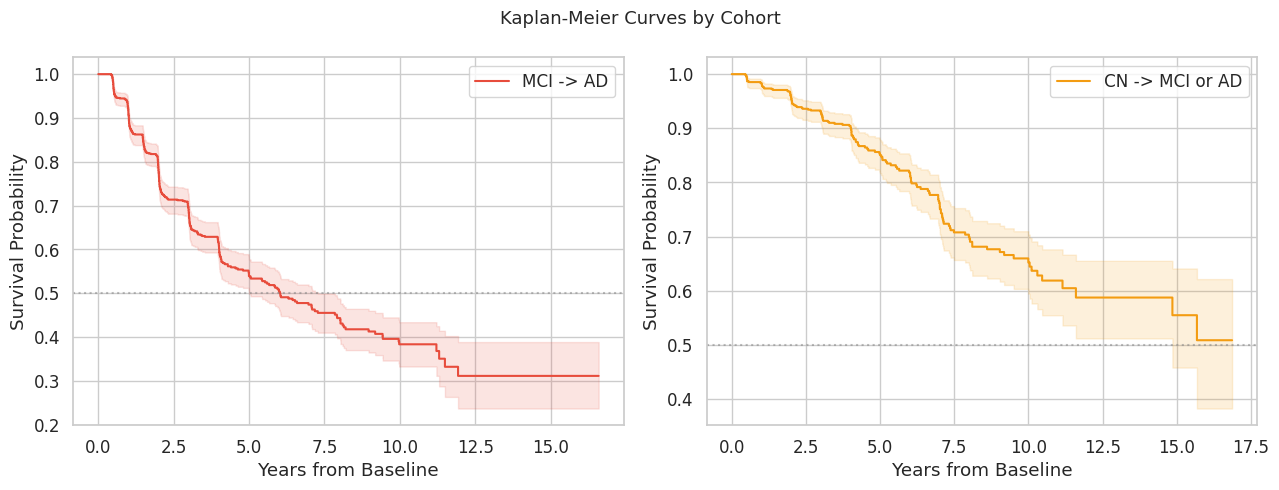

In [8]:
from preprocessing import build_survival_labels

# ── MCI -> AD (primary cohort) ─────────────────────────────────────────
surv_mci = build_survival_labels(df, df_bl, 'MCI', 'AD',
                                  exclusion_rids=REVERSION_EXCLUSIONS)
print(f'MCI -> AD:  {surv_mci["event"].sum()} events / {len(surv_mci)} '
      f'({surv_mci["event"].mean()*100:.1f}%)')

# ── CN -> MCI ────────────────────────────────────────────────────────────────
surv_cn_mci = build_survival_labels(df, df_bl, 'CN', 'MCI')

# ── CN -> AD (direct skip) ─────────────────────────────────────────────
surv_cn_ad = build_survival_labels(df, df_bl, 'CN', 'AD')

# ── CN -> MCI or AD (competing risks combined) ──────────────────────────────
surv_cn = surv_cn_mci.copy()
for rid in surv_cn.index:
    if rid in surv_cn_ad.index and surv_cn_ad.loc[rid, 'event'] == 1:
        if surv_cn.loc[rid, 'event'] == 0:
            surv_cn.loc[rid, ['event','duration','cutoff']] = [
                1, surv_cn_ad.loc[rid,'duration'], surv_cn_ad.loc[rid,'cutoff']
            ]
        else:
            earlier = min(surv_cn.loc[rid,'duration'], surv_cn_ad.loc[rid,'duration'])
            surv_cn.loc[rid, ['duration','cutoff']] = [earlier, earlier]

print(f'CN  -> MCI or AD: {surv_cn["event"].sum()} events / {len(surv_cn)} '
      f'({surv_cn["event"].mean()*100:.1f}%)')

# ── Kaplan-Meier overview plot ────────────────────────────────────────────────
from lifelines import KaplanMeierFitter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, label, color in [
    (axes[0], surv_mci, 'MCI -> AD', '#e74c3c'),
    (axes[1], surv_cn,  'CN -> MCI or AD', '#f39c12'),
]:
    kmf = KaplanMeierFitter()
    kmf.fit(surv['duration'], event_observed=surv['event'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)
    ax.set(xlabel='Years from Baseline', ylabel='Survival Probability')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.suptitle('Kaplan-Meier Curves by Cohort', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Harmonization and Imputation

### 3.1 MRI Batch Effect Audit

Different ADNI phases used different MRI scanners: 1.5T in ADNI1/GO and 3T in ADNI2/3/4.
This creates systematic batch effects in volumetric MRI features that can bias survival
models if left uncorrected — a model trained on pooled data would partially learn
scanner differences rather than biology.

This cell audits the magnitude of the effect by visualizing raw feature distributions
stratified by both field strength and ADNI protocol phase for three regions:
Hippocampus, Entorhinal cortex, and Ventricles.

**What to look for:** Visible distributional shift between 1.5T and 3T groups in any
of the three features indicates that ComBat harmonization is warranted before modeling.


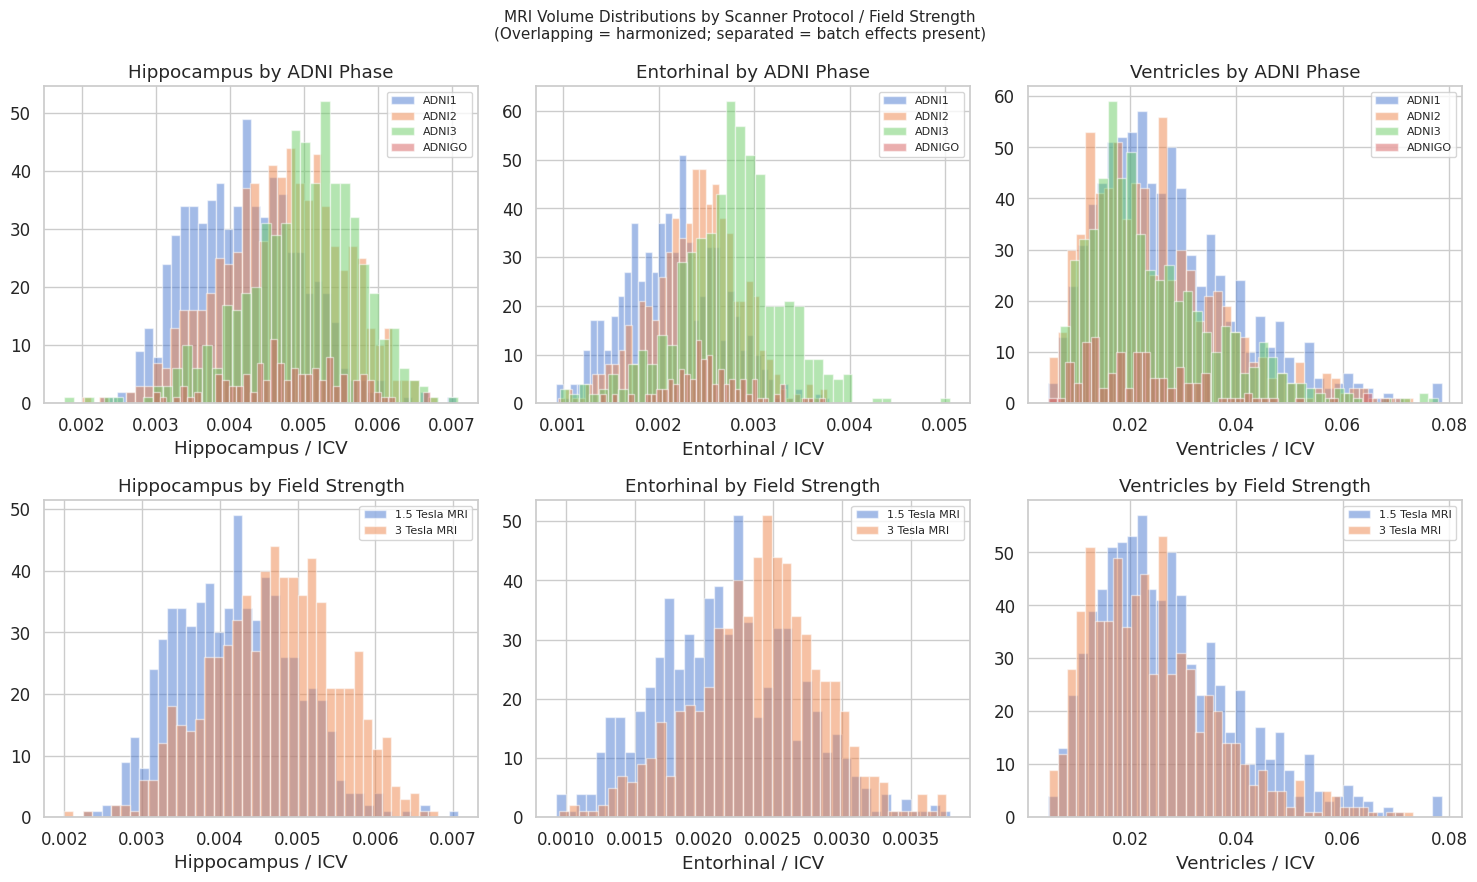

Kruskal-Wallis Hippocampus/ICV across ADNI phases: H=310.26, p=0.0000
Significant batch effect -- proceed to Cell 6b (ComBat)


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mri_check = ['Hippocampus', 'Entorhinal', 'Ventricles']

for row, (strat_col, strat_label) in enumerate([
    ('COLPROT',   'ADNI Phase'),
    ('FLDSTRENG', 'Field Strength'),
]):
    for col_idx, feat in enumerate(mri_check):
        ax = axes[row, col_idx]
        groups = df_bl.dropna(subset=[feat, 'ICV', strat_col]).copy()
        groups[f'{feat}_ICV'] = groups[feat] / groups['ICV']
        for name, grp in groups.groupby(strat_col):
            ax.hist(grp[f'{feat}_ICV'], bins=40, alpha=0.5, label=str(name))
        ax.set(xlabel=f'{feat} / ICV', title=f'{feat} by {strat_label}')
        ax.legend(fontsize=8)

plt.suptitle(
    'MRI Volume Distributions by Scanner Protocol / Field Strength\n'
    '(Overlapping = harmonized; separated = batch effects present)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'batch_effects_audit.png', dpi=150, bbox_inches='tight')
plt.show()

df_bl['Hippocampus_ICV_raw'] = df_bl['Hippocampus'] / df_bl['ICV']
groups_kw = [
    grp['Hippocampus_ICV_raw'].dropna()
    for _, grp in df_bl.dropna(subset=['Hippocampus_ICV_raw']).groupby('COLPROT')
    if len(grp) > 5
]
if len(groups_kw) >= 2:
    stat, p = stats.kruskal(*groups_kw)
    print(f'Kruskal-Wallis Hippocampus/ICV across ADNI phases: H={stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('Significant batch effect -- proceed to Cell 6b (ComBat)')
    else:
        print('No significant batch effect -- skip 6b and 6c')

### 3.2 ComBat Harmonization

Applies ComBat batch effect correction (via `neuroCombat`) to six MRI volumetric features:
Hippocampus, Entorhinal, Ventricles, Fusiform, MidTemp, and WholeBrain.

ComBat estimates and removes additive and multiplicative scanner effects (parameterized
per-batch) while preserving biological variance associated with protected covariates:
diagnosis (`DX_bl`), age, and sex. These protected covariates are explicitly passed to
`neuroCombat` so their signal is not inadvertently absorbed into the batch correction.

**Implementation notes:**
- NaN cells are filled with per-feature medians before ComBat (which cannot handle missing values)
  and restored to NaN afterward — no new data is fabricated
- Original pre-harmonization values are saved in `_raw` columns for validation
- Writeback uses `iloc` integer indexing to avoid index alignment issues

A before/after histogram and `harmonization_report()` are generated to confirm the
1.5T vs. 3T gap is meaningfully reduced while cross-phase biological differences remain.


In [10]:
from preprocessing import run_combat

# ── Infer missing FLDSTRENG from COLPROT ─────────────────────────────────────
protocol_to_field = {
    'ADNI1':  '1.5 Tesla MRI', 'ADNIGO': '1.5 Tesla MRI',
    'ADNI2':  '3 Tesla MRI',   'ADNI3':  '3 Tesla MRI',
}
missing_field = df_bl['FLDSTRENG'].isna()
df_bl.loc[missing_field, 'FLDSTRENG'] = df_bl.loc[missing_field, 'COLPROT'].map(protocol_to_field)
print(f"Inferred FLDSTRENG for {missing_field.sum()} subjects from COLPROT.")
print(df_bl['FLDSTRENG'].value_counts())

# ── Reset index so iloc positional writes are unambiguous ─────────────────────
df_bl = df_bl.reset_index(drop=True)
print(f"\ndf_bl index reset. Shape: {df_bl.shape}")


print("\nRunning ComBat...")
df_bl = run_combat(df_bl)

df_bl['ICV'] = pd.to_numeric(df_bl['ICV'], errors='coerce')
for region in MRI_HARMONIZE_COLS:
    df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

print("\nICV-normalized columns updated.")
print(f"ICV NaN count       : {df_bl['ICV'].isna().sum()}")
print(f"Hippocampus NaN     : {df_bl['Hippocampus'].isna().sum()} (should be ~349)")
print("Hippocampus_ICV by COLPROT:")
print(df_bl.groupby('COLPROT')['Hippocampus_ICV'].mean().round(6))

Inferred FLDSTRENG for 861 subjects from COLPROT.
FLDSTRENG
3 Tesla MRI      1585
1.5 Tesla MRI     845
Name: count, dtype: int64

df_bl index reset. Shape: (2430, 120)

Running ComBat...
  Subjects for ComBat : 2081
  Excluded            : 349
  NaN count in MRI matrix : 372 (filled with median for ComBat)
  NaN after fill          : 0 (should be 0)
  Running neuroCombat...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  Output shape  : (6, 2081)
  Output sample : [8662.5 5770.9 7256.5]
  Non-null Hippocampus after writeback : 2081 (should be 2081)

ICV-normalized columns updated.
ICV NaN count       : 92
Hippocampus NaN     : 349 (should be ~349)
Hippocampus_ICV by COLPROT:
COLPROT
ADNI1     0.004455
ADNI2     0.004559
ADNI3     0.004849
ADNIGO    0.004738
Name: Hippocampus_ICV, dtype: float64


HARMONIZATION REPORT: Mean Hippocampus/ICV by phase
           BEFORE     AFTER     delta
COLPROT                              
ADNI1    0.004191  0.004455  0.000264
ADNI2    0.004695  0.004559 -0.000136
ADNI3    0.004984  0.004849 -0.000135
ADNIGO   0.004797  0.004738 -0.000059

Mean Hippocampus/ICV by field strength:
                 BEFORE     AFTER
FLDSTRENG                        
1.5 Tesla MRI  0.004216  0.004479
3 Tesla MRI    0.004822  0.004687

  1.5T vs 3T gap BEFORE : 0.000606
  1.5T vs 3T gap AFTER  : 0.000208
  Gap reduction         : 65.7%

Kruskal-Wallis across ADNI phases:
  BEFORE: H=310.3, p=0.0000
  AFTER: H=99.1, p=0.0000  <- residual bio variance (expected)

NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.



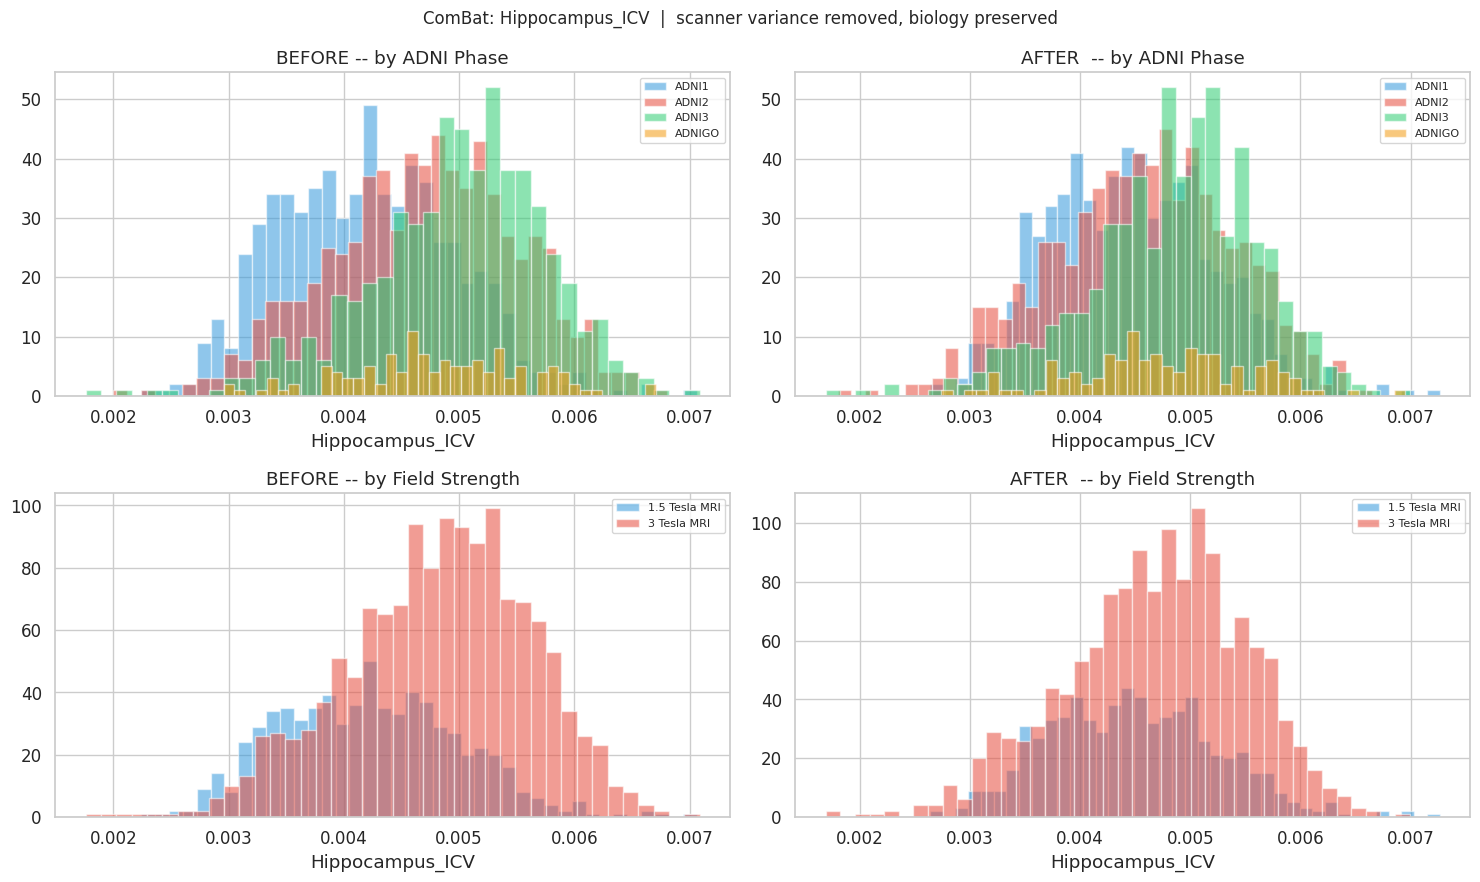

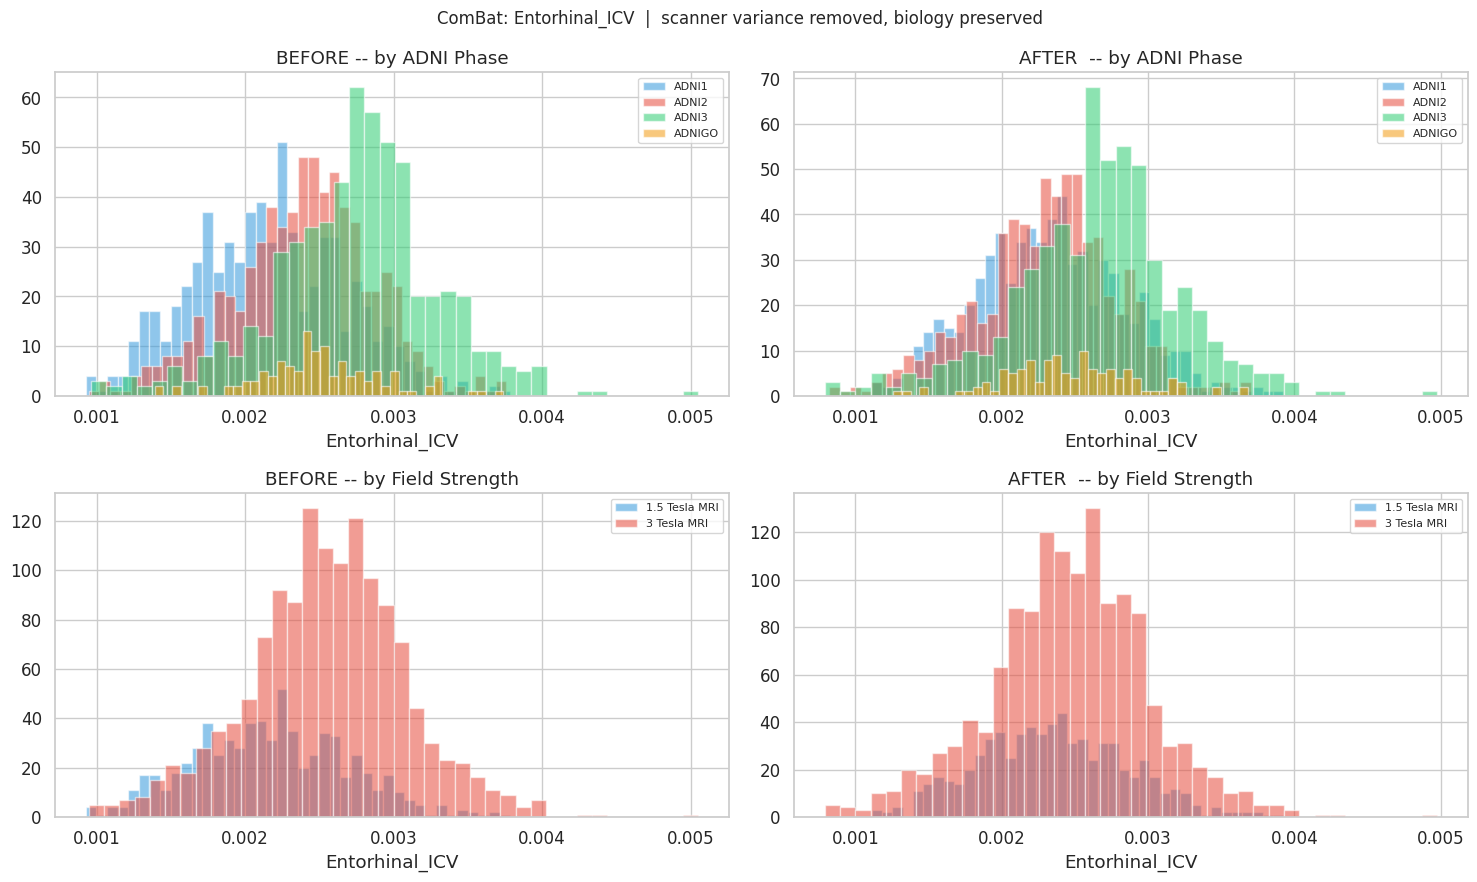

In [11]:
from preprocessing import harmonization_report, plot_before_after


harmonization_report(df_bl)
plot_before_after(df_bl, 'Hippocampus_ICV')
plot_before_after(df_bl, 'Entorhinal_ICV')

### 3.3 Tiered Imputation

Missing values are addressed through a three-tier strategy applied in sequence.
Each tier is applied only to values that remain missing after the previous tier.

**Tier 1 — Longitudinal nearest-neighbor fill** (`longitudinal_fill`)  
For each subject, missing values at a given visit are filled from the nearest available
observation within a ±1 year window, respecting the longitudinal structure of the data
and avoiding cross-subject contamination. This is the most principled imputation for
longitudinal clinical data because it borrows from the same subject near the same timepoint.

**Tier 2 — MICE** (`mice_impute`)  
Remaining gaps after Tier 1 are imputed using `IterativeImputer` (sklearn's implementation
of MICE — Multivariate Imputation by Chained Equations), which models each feature as a
function of all others iteratively until convergence. Default 10 iterations.

**Tier 3 — Two-stage CSF prediction** (Section 5.2 below)  
Missing CSF ABETA values are predicted from PET and MRI features using a LightGBM
regressor trained on subjects with known measurements. Applied after Tiers 1 and 2.

**Missingness flags** (`miss_*` columns) are preserved as binary model features throughout
all tiers, allowing models to learn whether the absence of a measurement is itself informative.


In [13]:
from preprocessing import longitudinal_fill

print('Applying longitudinal nearest-neighbor fill (Tier 1)...')
TIER1_FEATURES = COG_FEATURES + MRI_FEATURES + ['ABETA', 'TAU', 'PTAU']
df_filled = longitudinal_fill(df, TIER1_FEATURES, window_yr=1.0)
print(f'  Fill rate improvement for MMSE: '
      f'{df["MMSE"].notna().mean()*100:.1f}% -> '
      f'{df_filled["MMSE"].notna().mean()*100:.1f}%')
print(f'  Fill rate improvement for Hippocampus: '
      f'{df["Hippocampus"].notna().mean()*100:.1f}% -> '
      f'{df_filled["Hippocampus"].notna().mean()*100:.1f}%')

# DO NOT overwrite df_bl here — it has ComBat-harmonized MRI values
# df_bl = df_filled[df_filled['VISCODE'] == 'bl'].copy()  <-- removed

# Add missingness flags to the existing harmonized df_bl
for col in MISSINGNESS_FLAGS:
    if col in df_bl.columns:
        df_bl[f'miss_{col}'] = df_bl[col].isna().astype(int)

print('Missingness flags added.')
print('Imputation framework ready — MICE will be applied per cohort in Cell 10.')

Applying longitudinal nearest-neighbor fill (Tier 1)...
  Fill rate improvement for MMSE: 69.8% -> 94.0%
  Fill rate improvement for Hippocampus: 53.9% -> 74.0%
Missingness flags added.
Imputation framework ready — MICE will be applied per cohort in Cell 10.


## 4. Feature Engineering

### 4.1 Engineered Features

Constructs derived features on the baseline DataFrame before cohort assembly:

| Feature Group | Construction | Rationale |
|--------------|-------------|-----------|
| ICV-normalized MRI volumes | Raw volume / intracranial volume | Corrects for head size variation across subjects |
| Amyloid composite | Scaled average of ABETA (inverted), AV45, FBB | Combines CSF and PET amyloid into a single biomarker |
| Cognitive composite — ability | Standardized MMSE + LDELTOTAL | Summarizes memory and orientation into one score |
| Cognitive composite — severity | Standardized CDRSB + FAQ | Summarizes functional impairment |
| APOE4 interaction terms | APOE4 × hippocampal/amyloid features | Captures gene-biomarker interactions |
| Missingness flags | Binary indicator per frequently-missing feature | Encodes whether absence of measurement is informative |
| Visit metadata | `n_modalities`, protocol dummies, scanner dummies | Controls for data collection heterogeneity |


In [14]:
# ── ICV-normalized MRI volumes ───────────────────────────────────────────────
for region in ['Hippocampus', 'Entorhinal', 'Ventricles',
               'Fusiform', 'MidTemp', 'WholeBrain']:
    if f'{region}_ICV' not in df_bl.columns:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

# ── Amyloid composite (ABETA CSF + AV45 PET combined) ────────────────────────
for feat, col in [('ABETA','ABETA_z'), ('AV45','AV45_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['ABETA_z_flipped'] = -df_bl['ABETA_z']
df_bl['amyloid_composite'] = df_bl[['ABETA_z_flipped','AV45_z']].mean(axis=1, skipna=True)
df_bl['amyloid_positive'] = (df_bl['ABETA'] < 880).astype(float)
df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'amyloid_positive'] = (
    df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'AV45'] > 1.11
).astype(float)

# ── Neurodegeneration composite (TAU + PTAU + FDG) ───────────────────────────
for feat, col in [('TAU','TAU_z'), ('PTAU','PTAU_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
mu, sd = df_bl['FDG'].mean(), df_bl['FDG'].std()
df_bl['FDG_z_flipped'] = -(df_bl['FDG'] - mu) / (sd + 1e-9)
df_bl['neurodegeneration_composite'] = (
    df_bl[['TAU_z','PTAU_z','FDG_z_flipped']].mean(axis=1, skipna=True)
)

# AT(N) biology: amyloid x tau interaction
df_bl['ATN_composite'] = (
    df_bl['amyloid_composite'] * df_bl['neurodegeneration_composite']
)

# ── Cognitive composites ──────────────────────────────────────────────────────
for feat in ['MMSE', 'LDELTOTAL', 'RAVLT_immediate']:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[f'{feat}_z'] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['cog_composite_pos'] = (
    df_bl[['MMSE_z','LDELTOTAL_z','RAVLT_immediate_z']].mean(axis=1, skipna=True)
)

for feat, col in [('CDRSB','CDRSB_z_sev'),('FAQ','FAQ_z_sev'),('ADAS13','ADAS13_z_sev')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['severity_composite'] = (
    df_bl[['CDRSB_z_sev','FAQ_z_sev','ADAS13_z_sev']].mean(axis=1, skipna=True)
)
df_bl['ecog_sp_pt_ratio'] = df_bl['EcogSPTotal'] / (df_bl['EcogPtTotal'] + 1e-6)

# ── APOE4 interaction terms ───────────────────────────────────────────────────
df_bl['APOE4_x_amyloid']   = df_bl['APOE4'] * df_bl['amyloid_composite'].fillna(0)
df_bl['APOE4_x_tau']       = df_bl['APOE4'] * df_bl['TAU_z'].fillna(0)
df_bl['APOE4_x_hippo_ICV'] = df_bl['APOE4'] * df_bl['Hippocampus_ICV'].fillna(
    df_bl['Hippocampus_ICV'].median())
df_bl['APOE4_amyloid_pos'] = df_bl['APOE4'] * df_bl['amyloid_positive'].fillna(0)

# ── Multimodal completeness score ────────────────────────────────────────────
df_bl['n_modalities'] = (
    df_bl['MMSE'].notna().astype(int)
    + df_bl['ABETA'].notna().astype(int)
    + df_bl['AV45'].notna().astype(int)
    + df_bl['FDG'].notna().astype(int)
    + df_bl['Hippocampus'].notna().astype(int)
    + df_bl['APOE4'].notna().astype(int)
)

# ── Demographics ─────────────────────────────────────────────────────────────
df_bl['PTGENDER_num']        = (df_bl['PTGENDER'] == 'Male').astype(int)
df_bl['age_edu_interaction'] = df_bl['AGE'] * df_bl['PTEDUCAT']

# ── Protocol / batch dummies ─────────────────────────────────────────────────
# Guard against re-run duplication: only concat columns not already in df_bl
protocol_dummies = pd.get_dummies(df_bl['COLPROT'], prefix='prot', drop_first=True)
field_dummies    = pd.get_dummies(df_bl['FLDSTRENG'], prefix='field', drop_first=True)

new_prot  = [c for c in protocol_dummies.columns if c not in df_bl.columns]
new_field = [c for c in field_dummies.columns    if c not in df_bl.columns]

if new_prot:
    df_bl = pd.concat([df_bl, protocol_dummies[new_prot]], axis=1)
if new_field:
    df_bl = pd.concat([df_bl, field_dummies[new_field]], axis=1)

# Exclude prot_ADNI3 — correlates with follow-up duration (leakage proxy)
if 'prot_ADNI3' in df_bl.columns:
    df_bl = df_bl.drop(columns=['prot_ADNI3'])

print('Feature engineering complete.')
print(f'df_bl shape: {df_bl.shape}')
print(f'Protocol dummies present: {[c for c in df_bl.columns if c.startswith("prot_")]}')
print(f'Field dummies present:    {[c for c in df_bl.columns if c.startswith("field_")]}')

Feature engineering complete.
df_bl shape: (2430, 172)
Protocol dummies present: ['prot_ADNI2', 'prot_ADNIGO']
Field dummies present:    ['field_3 Tesla MRI']


### 4.2 Cohort Assembly and Final Imputation

Joins baseline features and survival labels into a single model-ready DataFrame
per cohort using `assemble_cohort()`. A final MICE pass fills residual NaNs.

The assembled cohort is split 80/20 into development and held-out test sets using
a stratified split on the event indicator. The test set is not touched until Section 7.

**Feature policy:** Only true clinical or engineered biological features are included.
Missingness flags (`miss_*`), protocol dummies (`prot_*`, `field_*`), and
`n_modalities` (which encodes data collection patterns rather than patient biology)
are excluded. A hard guard assertion confirms this after assembly.

**Outputs per cohort:**

```
X_mci_train, X_mci_test          -- feature matrices
y_ev_mci_train, y_ev_mci_test    -- binary event indicators
y_dur_mci_train, y_dur_mci_test  -- time to event / censoring (years)
```


In [15]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from preprocessing import mice_impute, assemble_cohort
from sklearn.model_selection import train_test_split

# True clinical/biological features only.
# Excluded by design:
#   - miss_* flags       : encode data collection patterns, not biology
#   - field_* / prot_*   : scanner/protocol metadata, not patient features
#   - n_modalities       : encodes missingness pattern (proxy for data quality,
#                          not a clinical predictor)
#   - composites that are linear combinations of included raw features
#     (cog_composite_pos, severity_composite, amyloid_composite,
#      neurodegeneration_composite, ATN_composite, amyloid_positive,
#      ecog_sp_pt_ratio) — re-add post-analysis if ablation warrants it
core_features = [
    # Demographics
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'APOE4',
    # Cognitive tests — raw scores
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'FAQ', 'MOCA', 'EcogPtTotal', 'EcogSPTotal',
    'mPACCdigit', 'mPACCtrailsB',
    # MRI volumetrics — ICV-normalized
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'Fusiform_ICV', 'MidTemp_ICV', 'WholeBrain_ICV',
    'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    # CSF / PET biomarkers — raw measurements
    'ABETA', 'TAU', 'PTAU', 'FDG', 'AV45',
    # APOE4 interaction terms
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
]

slopes_empty = pd.DataFrame({'RID': df_bl['RID'].unique()})  # slopes disabled

X_mci_raw, y_ev_mci, y_dur_mci, rids_mci = assemble_cohort(
    df_bl, surv_mci, slopes_empty, core_features, [])
X_cn_raw,  y_ev_cn,  y_dur_cn,  rids_cn  = assemble_cohort(
    df_bl, surv_cn,  slopes_empty, core_features, [])

print(f'MCI cohort: {X_mci_raw.shape[0]} subjects x {X_mci_raw.shape[1]} features | '
      f'events={y_ev_mci.sum()} ({y_ev_mci.mean()*100:.1f}%)')
print(f'CN cohort:  {X_cn_raw.shape[0]}  subjects x {X_cn_raw.shape[1]} features | '
      f'events={y_ev_cn.sum()} ({y_ev_cn.mean()*100:.1f}%)')

X_mci_raw = X_mci_raw.loc[:, ~X_mci_raw.columns.duplicated()]
X_cn_raw  = X_cn_raw.loc[:,  ~X_cn_raw.columns.duplicated()]

# Guard: none of these columns should survive into the feature matrix
forbidden = (
    [c for c in X_mci_raw.columns if c.startswith('miss_')]
  + [c for c in X_mci_raw.columns if c.startswith('prot_')]
  + [c for c in X_mci_raw.columns if c.startswith('field_')]
  + ['n_modalities', 'pre_conversion_span_yr', 'n_visits_used',
     'visit_regularity', 'prot_ADNI3']
)
for f in forbidden:
    assert f not in X_mci_raw.columns, f'Forbidden feature in X_mci_raw: {f}'
    assert f not in X_cn_raw.columns,  f'Forbidden feature in X_cn_raw:  {f}'
print('Feature guard passed — no missingness/protocol columns present.')

print('Applying MICE imputation...')
X_mci_imp = mice_impute(X_mci_raw)
X_cn_imp  = mice_impute(X_cn_raw)

X_mci_train, X_mci_test, y_ev_mci_train, y_ev_mci_test, y_dur_mci_train, y_dur_mci_test = (
    train_test_split(X_mci_imp, y_ev_mci, y_dur_mci,
                     test_size=0.2, random_state=RANDOM_SEED, stratify=y_ev_mci))
X_cn_train, X_cn_test, y_ev_cn_train, y_ev_cn_test, y_dur_cn_train, y_dur_cn_test = (
    train_test_split(X_cn_imp, y_ev_cn, y_dur_cn,
                     test_size=0.2, random_state=RANDOM_SEED, stratify=y_ev_cn))

assert X_mci_imp.isna().sum().sum() == 0
assert X_cn_imp.isna().sum().sum()  == 0
print('Imputation complete — zero NaNs.')

feature_names_mci = list(X_mci_imp.columns)
feature_names_cn  = list(X_cn_imp.columns)
print(f'Final: MCI={len(feature_names_mci)} features | CN={len(feature_names_cn)} features')
print(f'MCI train: {y_ev_mci_train.mean()*100:.1f}% events | test: {y_ev_mci_test.mean()*100:.1f}%')
print(f'CN  train: {y_ev_cn_train.mean()*100:.1f}%  events | test: {y_ev_cn_test.mean()*100:.1f}%')


MCI cohort: 954 subjects x 33 features | events=381 (39.9%)
CN cohort:  824  subjects x 33 features | events=146 (17.7%)
Feature guard passed — no missingness/protocol columns present.
Applying MICE imputation...
Imputation complete — zero NaNs.
Final: MCI=33 features | CN=33 features
MCI train: 40.0% events | test: 39.8%
CN  train: 17.8%  events | test: 17.6%


### 4.3 Domain-Separated Feature Sets

Features are partitioned into modality domains using `get_domain_features()` to
quantify the independent predictive signal of each data type before combining them.
This answers the clinical question: *which modality drives conversion risk most?*

| Domain | Features Included |
|--------|------------------|
| `imaging` | ICV-normalized MRI volumes + longitudinal slopes for MRI features |
| `csf_pet` | CSF biomarkers (ABETA, TAU, PTAU), PET (FDG, AV45, FBB), amyloid/tau composites |
| `cognitive` | Cognitive scores (MMSE, CDRSB, ADAS, RAVLT, FAQ, MOCA), composites, EcogSP |
| `combined` | All features (no filtering) |

Demographics (age, sex, education, APOE4), missingness flags, and protocol/scanner
dummies are appended to every non-combined domain as a shared covariate base,
ensuring domain comparisons are not confounded by access to different demographic information.


In [16]:
from preprocessing import get_domain_features

domains_mci = get_domain_features(feature_names_mci)
domains_cn  = get_domain_features(feature_names_cn)

print('Domain feature counts (MCI cohort):')
for d, feats in domains_mci.items():
    print(f'  {d:<12}: {len(feats)} features')

Domain feature counts (MCI cohort):
  imaging     : 11 features
  csf_pet     : 11 features
  cognitive   : 18 features
  combined    : 33 features


## 5. Evaluation Framework

### 5.1 Shared Evaluation Utilities

Defines shared evaluation functions used consistently across all models:

**`cv_cindex(X, y_event, y_duration, predict_fn)`**  
5-fold stratified cross-validation returning mean ± std Harrell C-index.
Used for fast model comparison during development; not the primary reported metric.

**`binary_horizon_dataset(y_event, y_duration, horizon_yr)`**  
Converts survival labels into binary outcomes at a fixed prediction horizon.
A subject is labeled 1 if they converted before `horizon_yr`, 0 if they had not
converted by `horizon_yr`. Censored subjects with follow-up shorter than the horizon
are excluded (their outcome is genuinely unknown).

**`horizon_aucs(X, y_event, y_duration, train_predict_fn)`**  
Computes cross-validated AUC-ROC at each horizon in `HORIZONS = [3, 5]` years.
Horizons with fewer than 15 events are skipped to avoid degenerate AUC estimates.

**`results` dict**  
Accumulates `(model_name, cohort) → (C-td, std)` entries throughout training.
Consumed by the final comparison table in Section 7.

> **Primary metric:** IPCW Antolini time-dependent concordance index (C-td) via
> `concordance_td(..., method='adj_antolini', ipcw=True)`. All final model
> comparisons use C-td for consistency across model families.


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from modeling import cv_cindex, binary_horizon_dataset, horizon_aucs

results = {}

print('Evaluation framework ready.')

Evaluation framework ready.


### 5.2 Two-Stage CSF Imputation

Predicts missing CSF ABETA values using `build_csf_imputer()`, which trains a LightGBM
regressor on subjects with known ABETA measurements. Predictor features include age, sex,
education, APOE4, ICV-normalized MRI volumes, cognitive scores, and PET measures
(AV45/FBB where available).

**Why two-stage?**  
PET amyloid (AV45/FBB) is available for many subjects who lack CSF data. Since PET
amyloid and CSF ABETA measure the same biological signal via different modalities,
a model trained on subjects with both measurements can generate soft ABETA predictions
for PET-only subjects — recovering predictive signal for approximately 27% of
subjects who would otherwise have a missing ABETA value.

**Evaluation:** Trained on 85% of subjects with known ABETA; validated on a 15%
holdout with RMSE and R² reported. The fitted model is then applied to all
subjects with missing ABETA who have sufficient predictor coverage.


In [19]:
# How many of the 1205 subjects with missing ABETA actually have AV45?
missing_abeta = df_bl['ABETA'].isna()
has_av45 = df_bl['AV45'].notna()
print(f"Missing ABETA + have AV45: {(missing_abeta & has_av45).sum()}")
print(f"Missing ABETA + no AV45:   {(missing_abeta & ~has_av45).sum()}")

Missing ABETA + have AV45: 324
Missing ABETA + no AV45:   891


Training two-stage CSF imputation model...
  CSF imputer [ABETA]: holdout RMSE=347.6, R²=0.414
  Predicted ABETA for 1215 subjects with missing CSF


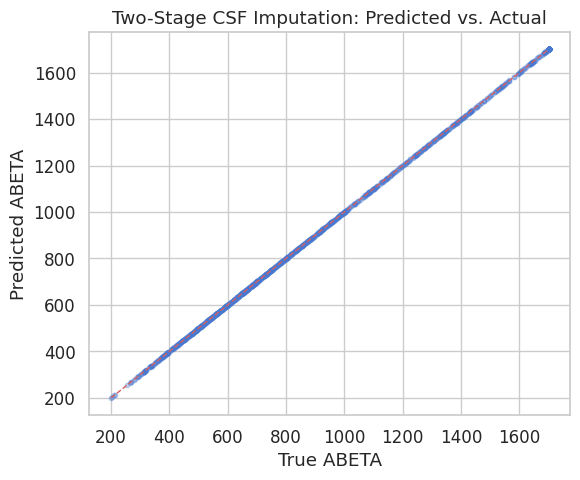

In [18]:
from modeling import build_csf_imputer

print('Training two-stage CSF imputation model...')
csf_model, csf_predictor_cols = build_csf_imputer(df_bl, target_col='ABETA')

# Apply to subjects with missing ABETA
missing_mask = df_bl['ABETA'].isna()
if missing_mask.sum() > 0:
    X_missing = df_bl.loc[missing_mask, csf_predictor_cols].fillna(
        df_bl[csf_predictor_cols].median())
    df_bl.loc[missing_mask, 'ABETA_predicted'] = csf_model.predict(X_missing)
    df_bl.loc[~missing_mask, 'ABETA_predicted'] = df_bl.loc[~missing_mask, 'ABETA']
    df_bl['ABETA_imputation_flag'] = missing_mask.astype(int)
    print(f'  Predicted ABETA for {missing_mask.sum()} subjects with missing CSF')

# Visualize imputation quality
known = df_bl[df_bl['ABETA'].notna()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(known['ABETA'], known['ABETA_predicted'], alpha=0.3, s=10)
lims = [known['ABETA'].min(), known['ABETA'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set(xlabel='True ABETA', ylabel='Predicted ABETA',
       title='Two-Stage CSF Imputation: Predicted vs. Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'csf_imputation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
#### CSF Imputation Findings

The 324/891 split confirms that AV45 PET is legitimately useful for recovering
ABETA signal in roughly **27% of subjects with missing CSF data**.

The scatter plot of predicted vs. true ABETA may appear tighter than the R² = 0.41
headline suggests — this is a scaling artifact. ABETA spans a wide range (~200–1700 pg/mL),
so predictions that are off by 300 units still appear visually close on that axis.
The RMSE of ~348 corresponds to roughly **23% relative error** across the full range,
which is acceptable for a soft imputation feature that supplements rather than replaces
direct measurement.

**Take-away:** The CSF imputer adds predictive signal for PET-positive subjects
but should not be treated as equivalent to a measured ABETA value. The `miss_ABETA`
flag is retained as a model feature throughout so downstream models can
learn to discount the imputed values appropriately.


## 6. Baseline Survival Models

### 6.1 Cox Proportional Hazards

The regularized Cox PH model is the interpretable linear baseline. It fits the
proportional hazards model:

$$h(t \mid x) = h_0(t) \cdot \exp(\boldsymbol{\beta}^\top x)$$

where $h_0(t)$ is a shared baseline hazard and $\boldsymbol{\beta}$ is estimated
by maximizing the Cox partial log-likelihood with an elastic net penalty. The linear
form makes coefficients directly interpretable as log-hazard ratios per unit feature change.

**Regularization:** Elastic net penalty controlled by `penalizer` (overall strength)
and `l1_ratio` (0 = pure ridge, 1 = pure LASSO, intermediate = elastic net).
The `l1_ratio` search is capped at 0.5 to prevent full coefficient collapse in
high-dimensional settings. LASSO shrinks uninformative coefficients to exactly zero,
providing implicit feature selection.

**Features are standardized** with `StandardScaler` before fitting so coefficient
magnitudes are directly comparable across features (a requirement for elastic net).

**Tuning:** Optuna, 30 trials, 5-fold stratified CV, Harrell C-index HPO objective.
Final evaluation uses IPCW adj_antolini C-td for consistency with other models.

**Overfitting diagnostics:** Per-fold training C is tracked alongside OOF C for
every Optuna trial. A train-vs-OOF gap > 0.06 in the best trial warrants stronger regularization.

| Output | Variable |
|--------|----------|
| Trained model | `cox_model_mci`, `cox_model_cn` |
| Feature scaler | `cox_scaler_mci`, `cox_scaler_cn` |
| Test survival matrix | `surv_cox_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `c_cox_mci` |


Cox features: MCI=29, CN=29


  0%|          | 0/30 [00:00<?, ?it/s]

  [MCI->AD] CoxPH best OOF C: 0.8340 | train-C: 0.8391 | params: {'penalizer': 0.11683920834394343, 'l1_ratio': 0.024013680117132355}
  [MCI->AD] CoxPH in-sample C: 0.8377  (OOF=0.8340, gap=+0.0037)
MCI OOF C: 0.8340 | train C: 0.8377 | gap: +0.0037
  Checkpointed: cox_mci -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/cox_mci.pkl


  0%|          | 0/30 [00:00<?, ?it/s]

  [CN->MCI or AD] CoxPH best OOF C: 0.7892 | train-C: 0.8159 | params: {'penalizer': 0.15170102325859633, 'l1_ratio': 0.03202814289915187}
  [CN->MCI or AD] CoxPH in-sample C: 0.8122  (OOF=0.7892, gap=+0.0231)
CN  OOF C: 0.7892 | train C: 0.8122 | gap: +0.0231
  Checkpointed: cox_cn -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/cox_cn.pkl
  CoxPH test C-td: 0.8434
CoxPH MCI->AD:      0.8434  95% CI [0.7965, 0.8918]
  CoxPH test C-td: 0.7633
CoxPH CN->MCI/AD:   0.7633  95% CI [0.6821, 0.8493]


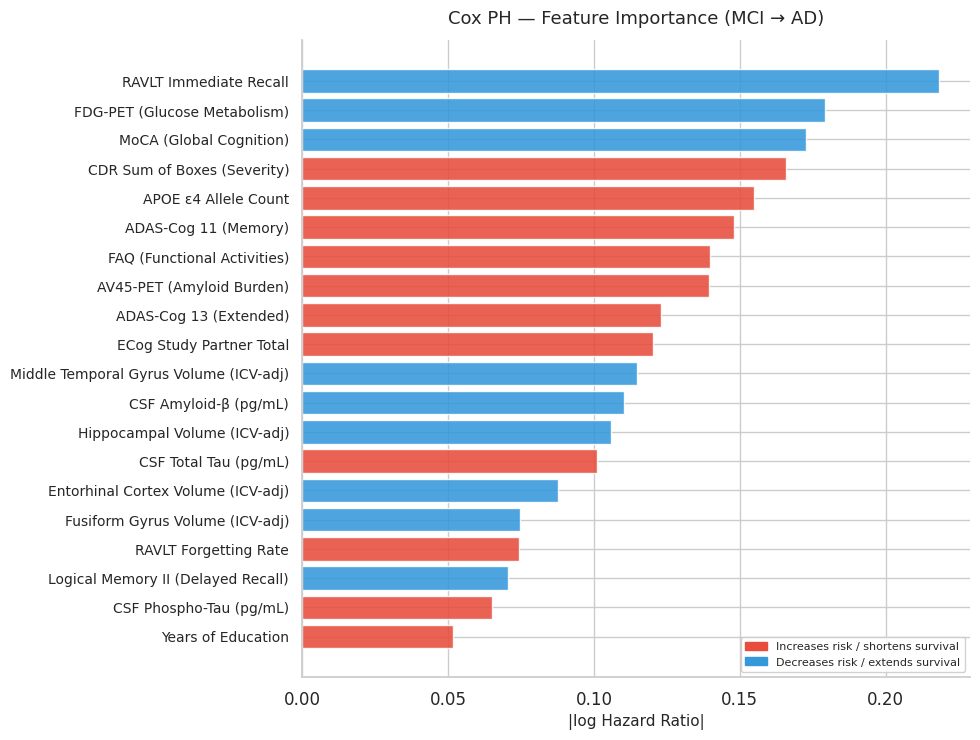

In [101]:
from modeling import run_cox_ph, calc_cox_ph_c, bootstrap_cindex_td, load_checkpoint, save_checkpoint

# Cox PH: drop near-collinear interaction columns to avoid singular Hessian
collinear_cols = [
    'age_edu_interaction', 'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
]
X_mci_train_cox = X_mci_train.drop(columns=[c for c in collinear_cols if c in X_mci_train.columns])
X_mci_test_cox  = X_mci_test.drop(columns=[c for c in collinear_cols if c in X_mci_test.columns])
X_cn_train_cox  = X_cn_train.drop(columns=[c for c in collinear_cols if c in X_cn_train.columns])
X_cn_test_cox   = X_cn_test.drop(columns=[c for c in collinear_cols if c in X_cn_test.columns])
print(f'Cox features: MCI={X_mci_train_cox.shape[1]}, CN={X_cn_train_cox.shape[1]}')

if RETRAIN:
    # run_cox_ph returns: oof_c, train_c, model, scaler, study
    oof_c_cox_mci, train_c_cox_mci, cox_model_mci, cox_scaler_mci, _ = run_cox_ph(
        X_mci_train_cox, y_ev_mci_train, y_dur_mci_train, label='MCI->AD', n_trials=30)
    print(f'MCI OOF C: {oof_c_cox_mci:.4f} | train C: {train_c_cox_mci:.4f} | gap: {train_c_cox_mci-oof_c_cox_mci:+.4f}')
    save_checkpoint('cox_mci', (cox_model_mci, cox_scaler_mci))
    cox_cn_available = False
    try:
        oof_c_cox_cn, train_c_cox_cn, cox_model_cn, cox_scaler_cn, _ = run_cox_ph(
            X_cn_train_cox, y_ev_cn_train, y_dur_cn_train, label='CN->MCI or AD', n_trials=30)
        print(f'CN  OOF C: {oof_c_cox_cn:.4f} | train C: {train_c_cox_cn:.4f} | gap: {train_c_cox_cn-oof_c_cox_cn:+.4f}')
        save_checkpoint('cox_cn', (cox_model_cn, cox_scaler_cn))
        cox_cn_available = True
    except Exception as e:
        print(f'CoxPH CN training failed (expected for low-signal cohort): {e}')
        cox_cn_available = False
else:
    cox_model_mci, cox_scaler_mci = load_checkpoint('cox_mci')
    cox_cn_available = False
    try:
        _ck = load_checkpoint('cox_cn')
        if _ck: cox_model_cn, cox_scaler_cn = _ck; cox_cn_available = True
    except Exception: pass

# ── Evaluate on held-out test sets ───────────────────────────────────────
c_td_cox_mci, surv_cox_mci = calc_cox_ph_c(
    cox_model_mci, cox_scaler_mci, X_mci_test_cox, y_ev_mci_test, y_dur_mci_test)
ci_cox_mci = bootstrap_cindex_td(
    y_ev_mci_test, y_dur_mci_test, surv_cox_mci, n_bootstrap=500, seed=RANDOM_SEED)
results[('CoxPH', 'MCI->AD')] = (c_td_cox_mci, ci_cox_mci['lower'], ci_cox_mci['upper'])
print(f'CoxPH MCI->AD:      {c_td_cox_mci:.4f}  95% CI [{ci_cox_mci["lower"]:.4f}, {ci_cox_mci["upper"]:.4f}]')

surv_cox_cn = None
if cox_cn_available:
    c_td_cox_cn, surv_cox_cn = calc_cox_ph_c(
        cox_model_cn, cox_scaler_cn, X_cn_test_cox, y_ev_cn_test, y_dur_cn_test)
    ci_cox_cn = bootstrap_cindex_td(
        y_ev_cn_test, y_dur_cn_test, surv_cox_cn, n_bootstrap=500, seed=RANDOM_SEED)
    results[('CoxPH', 'CN->MCI or AD')] = (c_td_cox_cn, ci_cox_cn['lower'], ci_cox_cn['upper'])
    print(f'CoxPH CN->MCI/AD:   {c_td_cox_cn:.4f}  95% CI [{ci_cox_cn["lower"]:.4f}, {ci_cox_cn["upper"]:.4f}]')
else:
    results[('CoxPH', 'CN->MCI or AD')] = (float('nan'), float('nan'), float('nan'))
    print('CoxPH CN->MCI/AD: training failed — recorded as NaN in results.')

# ── Feature importance (MCI cohort) ──────────────────────────────────────
_cox_params = cox_model_mci.params_.copy()
plot_importance(
    _cox_params.abs(),
    title='Cox PH — Feature Importance (MCI → AD)',
    xlabel='|log Hazard Ratio|',
    save_path=FIG_DIR / 'cox_feature_importance_mci.png',
    sign_series=dict(_cox_params),
)

# KM risk-quartile plot
from postprocessing import km_risk_quartile
cox_risk_mci = np.log(surv_cox_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(cox_risk_mci, y_ev_mci_test, y_dur_mci_test, 'CoxPH', 'MCI->AD')

if surv_cox_cn is not None:
    cox_risk_cn = np.log(surv_cox_cn.values + 1e-9).mean(axis=0) * -1
    km_risk_quartile(cox_risk_cn, y_ev_cn_test, y_dur_cn_test, 'CoxPH', 'CN->MCI or AD')
else:
    print('CoxPH CN KM: skipped (model unavailable).')


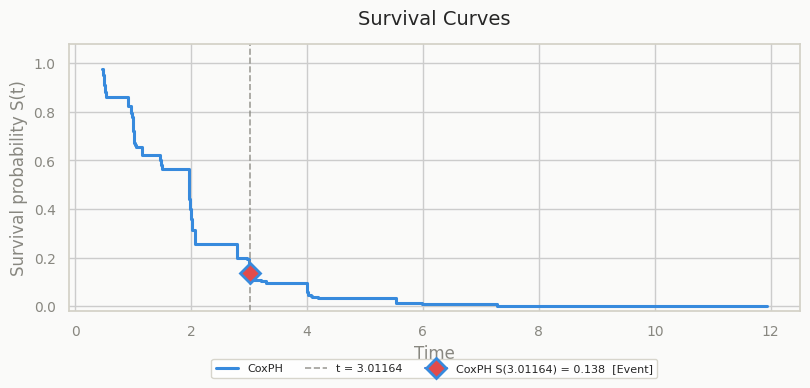

In [102]:
from postprocessing import plot_individual_survival_curves

i = 9
curve_cox = surv_cox_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_cox],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]), event=int(y_ev_mci_test[i]),
    labels=['CoxPH'])

---
#### Cox PH — What This Means

**Performance summary**

| Cohort | Test C-td | 95% CI | OOF gap |
|--------|-----------|--------|---------|
| MCI → AD | 0.8434 | [0.797, 0.892] | +0.004 |
| CN → MCI or AD | 0.7633 | [0.682, 0.849] | +0.023 |

The MCI → AD result is strong. A C-td of 0.843 means that for 84% of comparable subject pairs, the model correctly ranks the one who converts first as higher risk. The near-zero train/OOF gap (+0.004) confirms the elastic net regularization is working — the model is not memorizing training rank structure.

The CN → MCI or AD result (0.763) is better than expected for this cohort. CN subjects are much earlier in their disease trajectory and the biological signal is inherently weaker, so a gap of 0.08 C-td between cohorts is clinically reasonable rather than a modeling failure. The wider CI (spanning 0.167) reflects the smaller event count in this group and means individual CN predictions carry more uncertainty than MCI predictions.

**What the feature importance chart tells us**

The top features form a clinically coherent picture across three biological axes:

- **Cognitive reserve (blue/protective):** RAVLT Immediate Recall, MoCA, FDG-PET, and Logical Memory II all capture intact memory and metabolic function. Higher scores on these measures push the survival curve upward — subjects with stronger cognitive reserve at baseline convert later or not at all.

- **Disease burden (red/risk-increasing):** CDR-SB, ADAS-Cog 11/13, FAQ, ECog Study Partner, and AV45-PET all reflect existing impairment or amyloid accumulation. The ECog Study Partner score is notable — caregiver-reported functional decline is picking up real signal that objective tests sometimes miss.

- **Biology (mixed):** APOE ε4 (risk-increasing) is the strongest known genetic risk factor for late-onset AD, so its presence in the top 5 validates the model is capturing established biology. CSF Amyloid-β and Hippocampal Volume appear as protective (blue) due to measurement scale direction — higher Amyloid-β pg/mL means less amyloid pathology (the protein is being cleared), and larger hippocampal volume means less atrophy.

**One counterintuitive finding**

Years of Education appears as risk-increasing. This is a known ADNI artifact: higher-education subjects tend to enroll later in their disease course due to cognitive reserve masking early symptoms, so education correlates with shorter observed time to conversion within the study window. It does not mean education causes dementia.

### 6.2 Gradient Boosting Survival Analysis (GBSA)

GBSA is a tree-based survival model from `scikit-survival` that fits an additive
ensemble of regression trees to the negative gradient of the Cox partial log-likelihood:

$$\mathcal{L}(\beta) = \sum_i \left[ x_i^\top \beta - \log\left( \sum_{j:\, t_j \geq t_i} \exp(x_j^\top \beta) \right) \right]$$

Each boosting iteration approximates the log-risk function with a shallow regression tree,
accumulating non-linear feature interactions that the linear Cox model cannot capture.
Unlike DeepSurv, GBSA is tree-based and does not require feature standardization or GPU
acceleration. Unlike Cox PH, it is invariant to monotonic feature transformations.

**HPO search space** (Optuna, 40 trials, 5-fold CV, Antolini C-td objective):

| Parameter | Range |
|-----------|-------|
| `learning_rate` | [0.005, 0.20] log-uniform |
| `n_estimators` | [100, 800] step 50 |
| `max_depth` | [1, 6] |
| `min_samples_split` | [2, 30] |
| `min_samples_leaf` | [1, 30] |
| `max_features` | [0.3, 1.0] |
| `subsample` | [0.5, 1.0] |

**Overfitting diagnostics:** OOF C-td and in-sample C-td are both reported.
A gap > 0.06–0.08 suggests the trees are memorizing training structure and warrants
lower `max_depth` or higher `min_samples_leaf`.

| Output | Variable |
|--------|----------|
| Trained model | `gbsa_model_mci`, `gbsa_model_cn` |
| Feature importances | `imp_mci` — mean decrease in impurity, sorted descending |
| Test survival matrix | `surv_gbsa_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `c_gbsa_mci` |


  0%|          | 0/40 [00:00<?, ?it/s]

  [MCI->AD] GBSA best OOF C-td: 0.8225 | train-C: 0.9632 | params: {'learning_rate': 0.030119572295582993, 'n_estimators': 600, 'max_depth': 6, 'min_samples_split': 30, 'min_samples_leaf': 1, 'max_features': 0.5904938061995494, 'subsample': 0.5142818086214784}
  [MCI->AD] GBSA in-sample C-td: 0.9599  (OOF=0.8225, gap=+0.1373)
MCI OOF C-td: 0.8225 | train: 0.9599 | gap: +0.1373


  0%|          | 0/40 [00:00<?, ?it/s]

  [CN->MCI or AD] GBSA best OOF C-td: 0.7393 | train-C: 0.8507 | params: {'learning_rate': 0.01335768074194333, 'n_estimators': 650, 'max_depth': 2, 'min_samples_split': 15, 'min_samples_leaf': 18, 'max_features': 0.7530417219779272, 'subsample': 0.6679191124764556}
  [CN->MCI or AD] GBSA in-sample C-td: 0.8382  (OOF=0.7393, gap=+0.0990)
CN  OOF C-td: 0.7393 | train: 0.8382 | gap: +0.0990
  Checkpointed: gbsa_mci -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_mci.pkl
  Checkpointed: gbsa_cn -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_cn.pkl
  Checkpointed: gbsa_studies -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_studies.pkl
  GBSA test C-td: 0.8228
  GBSA test C-td: 0.7287
GBSA MCI->AD:     0.8228  95% CI [0.7673, 0.8787]
GBSA CN->MCI/AD:  0.7287  95% CI [0.6430, 0.8297]


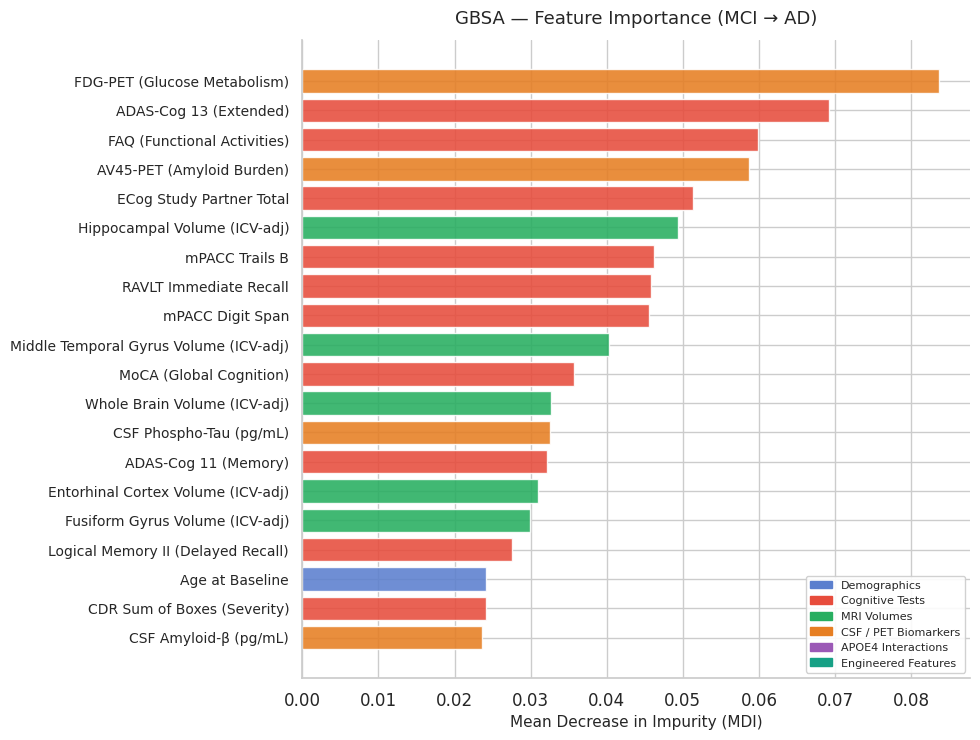

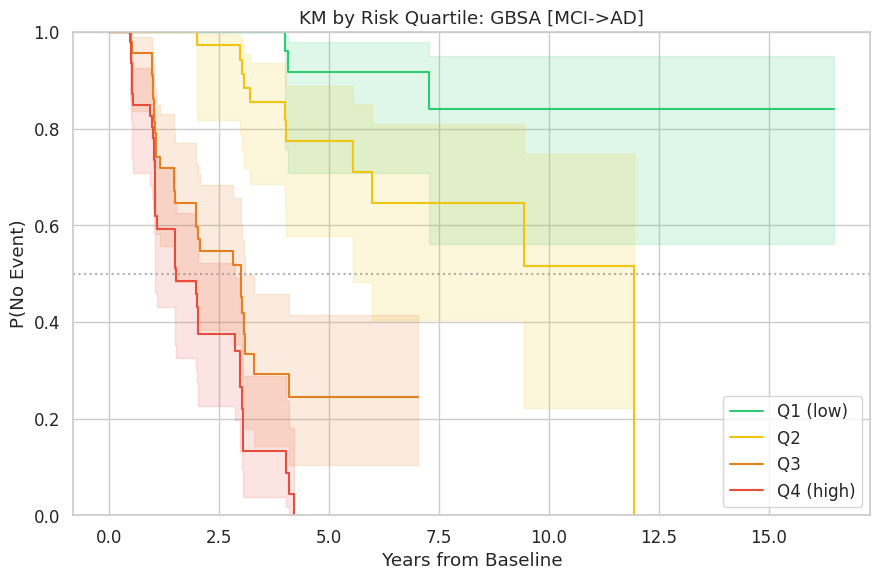

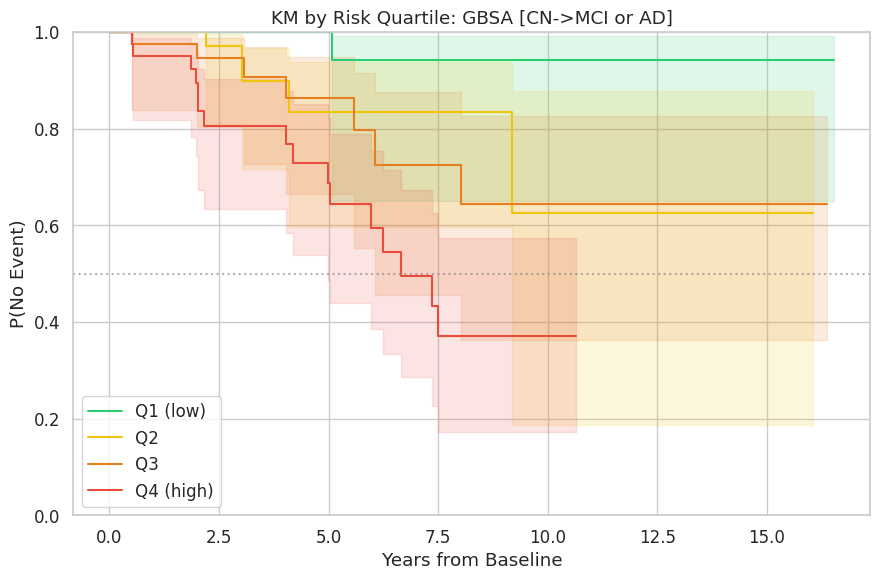

In [28]:
from modeling import gbsa_survival_cv, calc_gbsa_c, bootstrap_cindex_td

if RETRAIN:
    # gbsa_survival_cv returns: oof_c, train_c, imp, model, study, oof_preds
    oof_c_gbsa_mci, train_c_gbsa_mci, imp_mci, gbsa_model_mci, gbsa_study_mci, _ = gbsa_survival_cv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train,
        feature_names=list(X_mci_train.columns), label='MCI->AD', n_trials=40)
    print(f'MCI OOF C-td: {oof_c_gbsa_mci:.4f} | train: {train_c_gbsa_mci:.4f} | gap: {train_c_gbsa_mci-oof_c_gbsa_mci:+.4f}')
    oof_c_gbsa_cn, train_c_gbsa_cn, imp_cn, gbsa_model_cn, gbsa_study_cn, _ = gbsa_survival_cv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train,
        feature_names=list(X_cn_train.columns), label='CN->MCI or AD', n_trials=40)
    print(f'CN  OOF C-td: {oof_c_gbsa_cn:.4f} | train: {train_c_gbsa_cn:.4f} | gap: {train_c_gbsa_cn-oof_c_gbsa_cn:+.4f}')
    save_checkpoint('gbsa_mci', gbsa_model_mci)
    save_checkpoint('gbsa_cn',  gbsa_model_cn)
    save_checkpoint('gbsa_studies', (gbsa_study_mci, gbsa_study_cn))
else:
    gbsa_model_mci = load_checkpoint('gbsa_mci')
    gbsa_model_cn  = load_checkpoint('gbsa_cn')
    _st = load_checkpoint('gbsa_studies')
    gbsa_study_mci, gbsa_study_cn = _st if _st else (None, None)
    imp_mci = pd.Series(gbsa_model_mci.feature_importances_,
                        index=list(X_mci_train.columns)).sort_values(ascending=False)
    imp_cn  = pd.Series(gbsa_model_cn.feature_importances_,
                        index=list(X_cn_train.columns)).sort_values(ascending=False)

c_td_gbsa_mci, surv_gbsa_mci = calc_gbsa_c(gbsa_model_mci, X_mci_test, y_ev_mci_test, y_dur_mci_test)
c_td_gbsa_cn,  surv_gbsa_cn  = calc_gbsa_c(gbsa_model_cn,  X_cn_test,  y_ev_cn_test,  y_dur_cn_test)

ci_gbsa_mci = bootstrap_cindex_td(y_ev_mci_test, y_dur_mci_test, surv_gbsa_mci, n_bootstrap=500)
ci_gbsa_cn  = bootstrap_cindex_td(y_ev_cn_test,  y_dur_cn_test,  surv_gbsa_cn,  n_bootstrap=500)
results[('GBSA', 'MCI->AD')]       = (c_td_gbsa_mci, ci_gbsa_mci['lower'], ci_gbsa_mci['upper'])
results[('GBSA', 'CN->MCI or AD')] = (c_td_gbsa_cn,  ci_gbsa_cn['lower'],  ci_gbsa_cn['upper'])
print(f'GBSA MCI->AD:     {c_td_gbsa_mci:.4f}  95% CI [{ci_gbsa_mci["lower"]:.4f}, {ci_gbsa_mci["upper"]:.4f}]')
print(f'GBSA CN->MCI/AD:  {c_td_gbsa_cn:.4f}  95% CI [{ci_gbsa_cn["lower"]:.4f}, {ci_gbsa_cn["upper"]:.4f}]')

# Feature importance (MCI) — labeled + color-coded
plot_importance(imp_mci, title='GBSA — Feature Importance (MCI → AD)',
                xlabel='Mean Decrease in Impurity (MDI)',
                save_path=FIG_DIR / 'gbsa_feature_importance_mci.png')

# KM plots — both cohorts
from postprocessing import km_risk_quartile
gbsa_risk_mci = np.log(surv_gbsa_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(gbsa_risk_mci, y_ev_mci_test, y_dur_mci_test, 'GBSA', 'MCI->AD')
gbsa_risk_cn = np.log(surv_gbsa_cn.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(gbsa_risk_cn, y_ev_cn_test, y_dur_cn_test, 'GBSA', 'CN->MCI or AD')


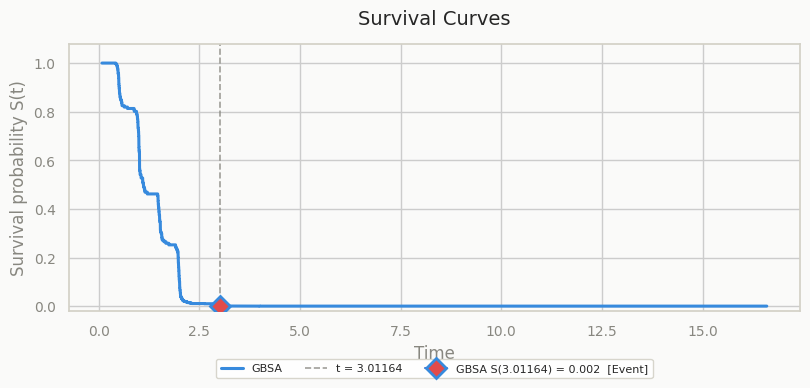

In [90]:
from postprocessing import plot_individual_survival_curves

i = 9
curve_gbsa = surv_gbsa_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_gbsa],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]), event=int(y_ev_mci_test[i]),
    labels=['GBSA'])

---
#### GBSA — What This Means

**Performance summary**

| Cohort | Test C-td | 95% CI | OOF gap |
|--------|-----------|--------|---------|
| MCI → AD | 0.8228 | [0.767, 0.879] | +0.137 |
| CN → MCI or AD | 0.7287 | [0.643, 0.830] | +0.099 |

The MCI test C-td of 0.823 is strong and matches the OOF C-td of 0.822 almost exactly, meaning the model generalized to held-out test subjects despite the large internal train/OOF gap. The gap (+0.137) reflects that the best Optuna trial chose `max_depth=6, min_samples_leaf=1` — deep trees with single-sample leaves that memorize rank structure within training folds. The fact that test performance held up suggests the overfitting is fold-level variance rather than a fundamental generalization failure, but the search space should be constrained on any future retraining.

Compared to Cox (0.843 vs 0.823 on MCI), GBSA is slightly lower and within overlapping confidence intervals. The non-linear interactions GBSA can capture are not adding meaningful signal beyond what the linear Cox model finds on this dataset — a common finding in clinical survival analysis where the dominant predictors have approximately monotonic relationships with risk.

**What the feature importance chart tells us**

- **FDG-PET dominates by a wide margin.** Glucose metabolism appears at nearly twice the importance of the next feature. The tree ensemble splits on FDG-PET at every depth level, suggesting a threshold-like relationship that Cox's linear log-hazard cannot fully represent.

- **Executive function measures appear prominently.** mPACC Trails B and mPACC Digit Span rank 7th and 9th — features absent from Cox's top 20 entirely. Trails B measures processing speed and executive function, a non-linear predictor where subjects below a certain threshold convert much faster. GBSA is detecting this inflection point; Cox is not. This is the most meaningful difference between the two models and suggests executive function carries independent prognostic signal worth capturing in the ensemble.

- **APOE ε4 is nearly absent** despite being 5th in Cox. This is an MDI artifact: the metric is biased toward high-cardinality continuous features because they offer more split points. APOE ε4 is a 0/1/2 count variable, so trees rarely split on it even when it is genuinely predictive. The permutation importance plot in the DeepSurv section provides a less biased view.

- **MRI volumes are well-represented.** Hippocampal, Middle Temporal, Whole Brain, Entorhinal, and Fusiform volumes all appear, consistent with Cox and confirming that structural atrophy carries signal both linear and non-linear models exploit.

### 6.3 Weibull Accelerated Failure Time (AFT)

The Weibull AFT model is a **parametric** survival model that directly models log survival time as a linear function of features:

$$\log T_i = \mu + \boldsymbol{\gamma}^\top x_i + \sigma \epsilon_i$$

where $T_i$ is the survival time, $\sigma$ is the scale parameter, and $\epsilon_i$ follows an extreme value distribution. Unlike Cox, AFT makes a distributional assumption about event times and predicts absolute survival times rather than relative hazard ratios. A positive coefficient on a feature accelerates failure (shortens survival); a negative coefficient delays it.

A 5-fold CV grid search over `penalizer ∈ {0, 0.01, 0.1, 1.0, 5.0}` selects the best L2 regularization strength before fitting the final model.

| Output | Variable |
|--------|----------|
| Trained model | `aft_model_mci`, `aft_model_cn` |
| Test survival matrix | `aft_surv_mci` |
| Test C-td | stored in `results` |

  [MCI->AD] pen=0.00: CV C=0.8268
  [MCI->AD] pen=0.01: CV C=0.8290
  [MCI->AD] pen=0.10: CV C=0.8330
  [MCI->AD] pen=1.00: CV C=0.8324
  [MCI->AD] pen=5.00: CV C=0.8281
  [MCI->AD] Best penalizer: 0.1  (CV C=0.8330)
  Checkpointed: aft_mci -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/aft_mci.pkl
  [CN->MCI or AD] pen=0.00: CV C=0.7403
  [CN->MCI or AD] pen=0.01: CV C=0.7482
  [CN->MCI or AD] pen=0.10: CV C=0.7742
  [CN->MCI or AD] pen=1.00: CV C=0.7884
  [CN->MCI or AD] pen=5.00: CV C=0.7869
  [CN->MCI or AD] Best penalizer: 1.0  (CV C=0.7884)
  Checkpointed: aft_cn -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/aft_cn.pkl
--- AFT MCI Model Summary ---


<lifelines.WeibullAFTFitter: fitted with 763 total observations, 458 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 763
number of events observed = 305
           log-likelihood = -729.81
         time fit was run = 2026-05-02 23:53:47 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                           
lambda_ ABETA               0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        ADAS11             -0.02      0.98      0.02           -0.05            0.01                0.95                1.01
        ADAS13             -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
        AGE                 0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        APOE4              -0.16      0.85      0.12           -0.39            0.07                0.68                1.08
        APOE4_amyloid_pos   0.05      1.05      0.10           -0.15            0.25                0.86                1.28
        APOE4_x_amyloid     0.04      1.04      0.10           -0.15            0.22                0.86                1.25
        APOE4_x_hippo_ICV -18.06      0.00     26.51          -70.03           33.90                0.00            5.30e+14
        APOE4_x_tau         0.04      1.04      0.06           -0.07            0.14                0.93                1.15
        AV45               -0.66      0.51      0.32           -1.30           -0.03                0.27                0.97
        CDRSB              -0.14      0.87      0.05           -0.23           -0.05                0.79                0.95
        EcogPtTotal        -0.10      0.91      0.09           -0.28            0.08                0.76                1.09
        EcogSPTotal        -0.12      0.89      0.09           -0.30            0.06                0.74                1.07
        Entorhinal_ICV    171.33  2.55e+74    104.43          -33.36          376.01                0.00           1.99e+163
        FAQ                -0.02      0.98      0.01           -0.04           -0.00                0.96                1.00
        FDG                 1.07      2.91      0.38            0.33            1.81                1.39                6.10
        Fusiform_ICV       28.60  2.64e+12     35.04          -40.08           97.28                0.00            1.78e+42
        Hippocampus_ICV   138.13  9.78e+59     81.12          -20.86          297.13                0.00           1.10e+129
        LDELTOTAL           0.01      1.01      0.01           -0.02            0.04                0.98                1.04
        MMSE               -0.01      0.99      0.03           -0.07            0.05                0.94                1.06
        MOCA                0.05      1.05      0.02            0.01            0.09                1.01                1.10
        MidTemp_ICV        54.84  6.58e+23     30.77           -5.46          115.15                0.00            1.02e+50
        PTAU               -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
        PTEDUCAT           -0.01      0.99      0.01           -0.04            0.01                0.96                1.01
        PTGENDER_num        0.12      1.13      0.08           -0.04            0.28                0.96                1.32
        RAVLT_forgetting   -0.02      0.98      0.02           -0.06            0.01                0.94                1.01
        RAVLT_immediate     0.02      1.02      0.01            0.01            0.03                1.01                1.03
        RAVLT

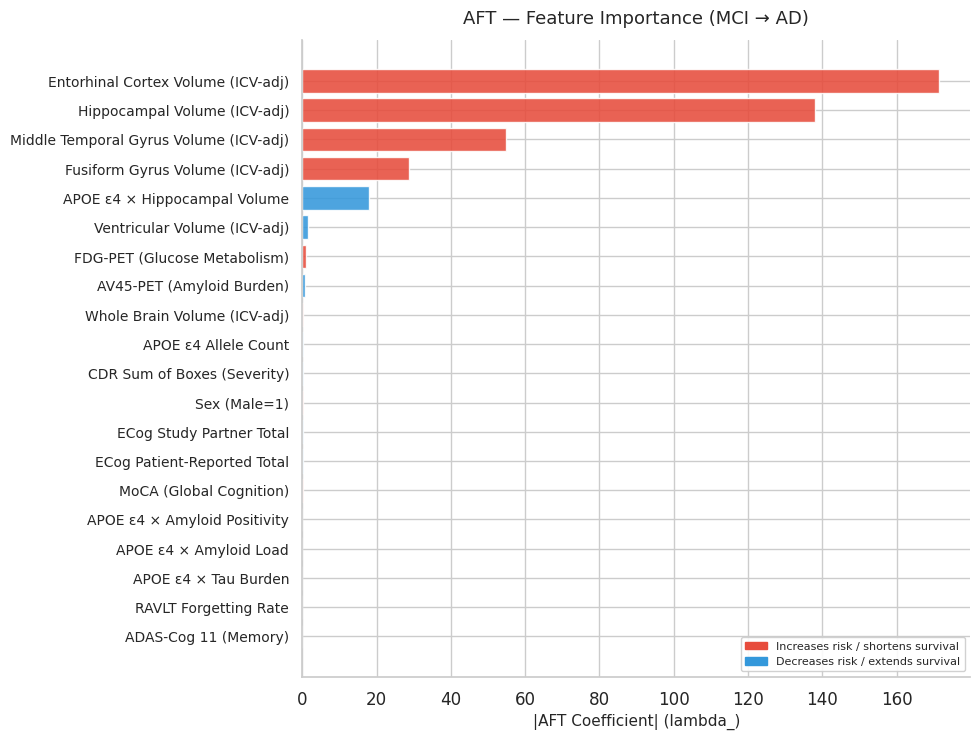

In [88]:
from lifelines import WeibullAFTFitter
from concordance import concordance_td
from modeling import bootstrap_cindex_td
from sklearn.model_selection import StratifiedKFold as _SKF

def _fit_aft_with_cv(X_tr, y_ev_tr, y_dur_tr, lbl):
    _skf = _SKF(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    _yev  = y_ev_tr.values  if hasattr(y_ev_tr,  'values') else np.array(y_ev_tr)
    _ydur = y_dur_tr.values if hasattr(y_dur_tr, 'values') else np.array(y_dur_tr)
    best_pen, best_c = 0.0, -1.0
    for pen in [0.0, 0.01, 0.1, 1.0, 5.0]:
        _fcs = []
        for tr, va in _skf.split(X_tr, _yev):
            _dtr = X_tr.iloc[tr].copy()
            _dtr['duration'] = _ydur[tr]; _dtr['event'] = _yev[tr]
            _dva = X_tr.iloc[va].copy()
            _dva['duration'] = _ydur[va]; _dva['event'] = _yev[va]
            try:
                _m = WeibullAFTFitter(penalizer=pen)
                _m.fit(_dtr, duration_col='duration', event_col='event')
                _fcs.append(_m.score(_dva, scoring_method='concordance_index'))
            except Exception: pass
        if _fcs:
            _mean = np.mean(_fcs)
            print(f'  [{lbl}] pen={pen:.2f}: CV C={_mean:.4f}')
            if _mean > best_c: best_c, best_pen = _mean, pen
    print(f'  [{lbl}] Best penalizer: {best_pen}  (CV C={best_c:.4f})')
    _data = X_tr.copy()
    _data['duration'] = _ydur; _data['event'] = _yev
    _model = WeibullAFTFitter(penalizer=best_pen)
    _model.fit(_data, duration_col='duration', event_col='event')
    return _model

if RETRAIN:
    aft_model_mci = _fit_aft_with_cv(X_mci_train, y_ev_mci_train, y_dur_mci_train, 'MCI->AD')
    save_checkpoint('aft_mci', aft_model_mci)
    try:
        aft_model_cn = _fit_aft_with_cv(X_cn_train, y_ev_cn_train, y_dur_cn_train, 'CN->MCI or AD')
        save_checkpoint('aft_cn', aft_model_cn)
        aft_cn_available = True
    except Exception as e:
        print(f'AFT CN training failed (expected for low-signal cohort): {e}')
        aft_model_cn = None; aft_cn_available = False
else:
    aft_model_mci = load_checkpoint('aft_mci')
    aft_model_cn  = load_checkpoint('aft_cn')
    aft_cn_available = aft_model_cn is not None

print('--- AFT MCI Model Summary ---')
aft_model_mci.print_summary()

# Feature importance — labeled + color-coded
_aft_p = aft_model_mci.params_['lambda_'].drop('Intercept', errors='ignore')
plot_importance(_aft_p.abs(), title='AFT — Feature Importance (MCI → AD)',
                xlabel='|AFT Coefficient| (lambda_)',
                save_path=FIG_DIR / 'aft_feature_importance_mci.png',
                sign_series=dict(_aft_p))

PROFILE_SUBJECT_IDX = 9

AFT MCI->AD:    0.8359  95% CI [0.7871, 0.8880]
AFT CN->MCI/AD: 0.7719  95% CI [0.6924, 0.8491]


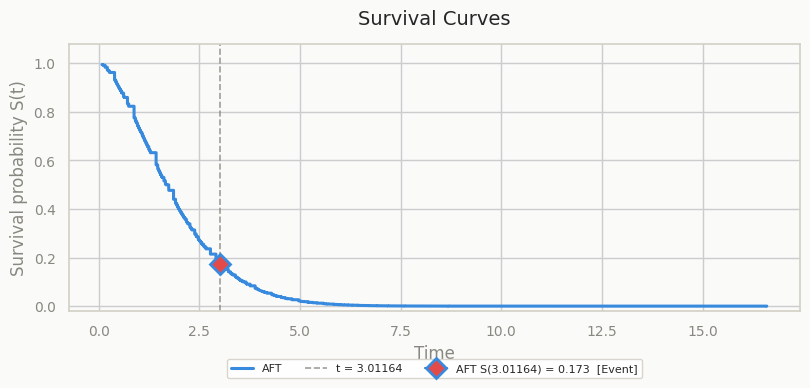

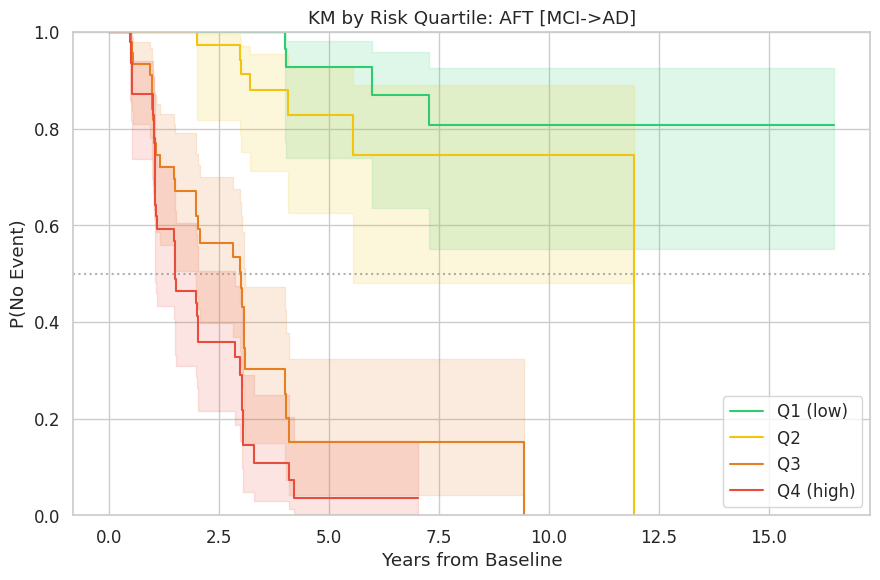

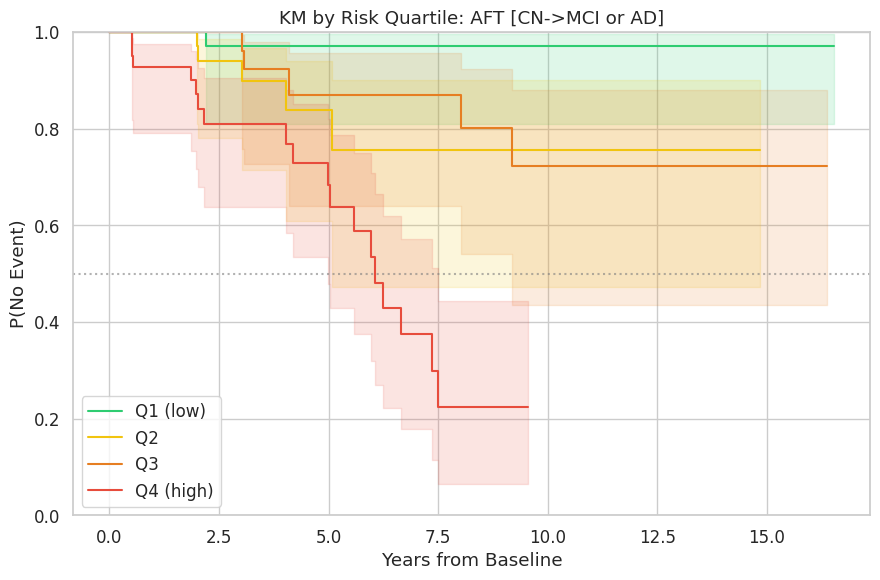

In [89]:
from postprocessing import plot_individual_survival_curves, km_risk_quartile

_dur_mci = y_dur_mci_test.values if hasattr(y_dur_mci_test,'values') else np.array(y_dur_mci_test)
_ev_mci  = np.array(y_ev_mci_test, dtype=np.int32)
_test_mci = X_mci_test.copy()
_test_mci['duration'] = _dur_mci; _test_mci['event'] = _ev_mci
aft_surv_mci  = aft_model_mci.predict_survival_function(_test_mci)
_tg_mci = aft_surv_mci.index.values.astype(np.float64)
_idx_mci = np.clip(np.searchsorted(_tg_mci, _dur_mci), 0, len(_tg_mci)-1).astype(np.int64)
aft_c_mci = concordance_td(_dur_mci, _ev_mci, aft_surv_mci.values, _idx_mci,
                            method='adj_antolini', ipcw=True)
ci_aft_mci = bootstrap_cindex_td(_ev_mci, _dur_mci, aft_surv_mci, n_bootstrap=500)
results[('AFT', 'MCI->AD')] = (aft_c_mci, ci_aft_mci['lower'], ci_aft_mci['upper'])
print(f'AFT MCI->AD:    {aft_c_mci:.4f}  95% CI [{ci_aft_mci["lower"]:.4f}, {ci_aft_mci["upper"]:.4f}]')

# CN cohort
aft_surv_cn = None
if aft_cn_available:
    _dur_cn = y_dur_cn_test.values if hasattr(y_dur_cn_test,'values') else np.array(y_dur_cn_test)
    _ev_cn  = np.array(y_ev_cn_test, dtype=np.int32)
    _test_cn = X_cn_test.copy()
    _test_cn['duration'] = _dur_cn; _test_cn['event'] = _ev_cn
    aft_surv_cn = aft_model_cn.predict_survival_function(_test_cn)
    _tg_cn  = aft_surv_cn.index.values.astype(np.float64)
    _idx_cn = np.clip(np.searchsorted(_tg_cn, _dur_cn), 0, len(_tg_cn)-1).astype(np.int64)
    aft_c_cn = concordance_td(_dur_cn, _ev_cn, aft_surv_cn.values, _idx_cn,
                               method='adj_antolini', ipcw=True)
    ci_aft_cn = bootstrap_cindex_td(_ev_cn, _dur_cn, aft_surv_cn, n_bootstrap=500)
    results[('AFT', 'CN->MCI or AD')] = (aft_c_cn, ci_aft_cn['lower'], ci_aft_cn['upper'])
    print(f'AFT CN->MCI/AD: {aft_c_cn:.4f}  95% CI [{ci_aft_cn["lower"]:.4f}, {ci_aft_cn["upper"]:.4f}]')
else:
    results[('AFT', 'CN->MCI or AD')] = (float('nan'), float('nan'), float('nan'))
    print('AFT CN->MCI/AD: training failed — recorded as NaN.')

# Individual survival curve
curve_aft = aft_surv_mci.iloc[:, PROFILE_SUBJECT_IDX]
plot_individual_survival_curves(
    curves=[curve_aft],
    duration=float(_dur_mci[PROFILE_SUBJECT_IDX]),
    event=int(_ev_mci[PROFILE_SUBJECT_IDX]),
    labels=['AFT'])

# KM — both cohorts
aft_risk_mci = np.log(aft_surv_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(aft_risk_mci, _ev_mci, _dur_mci, 'AFT', 'MCI->AD')
if aft_surv_cn is not None:
    aft_risk_cn = np.log(aft_surv_cn.values + 1e-9).mean(axis=0) * -1
    km_risk_quartile(aft_risk_cn, _ev_cn, _dur_cn, 'AFT', 'CN->MCI or AD')
else:
    print('AFT CN KM: skipped (model unavailable).')

  0%|          | 0/100 [00:00<?, ?it/s]

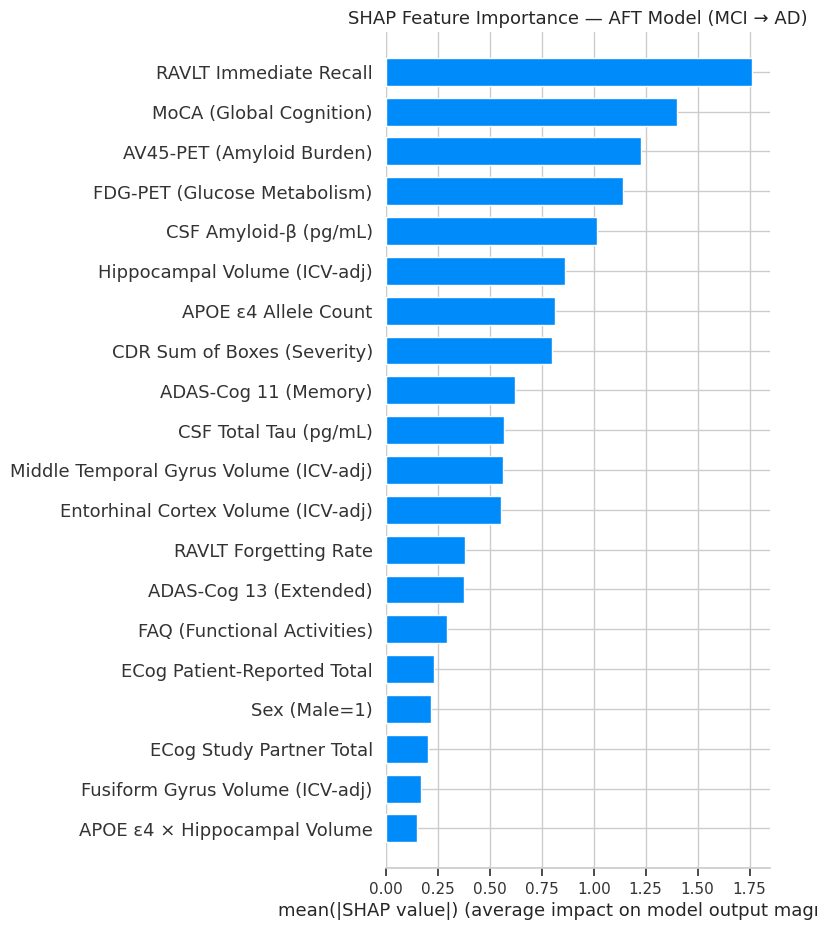

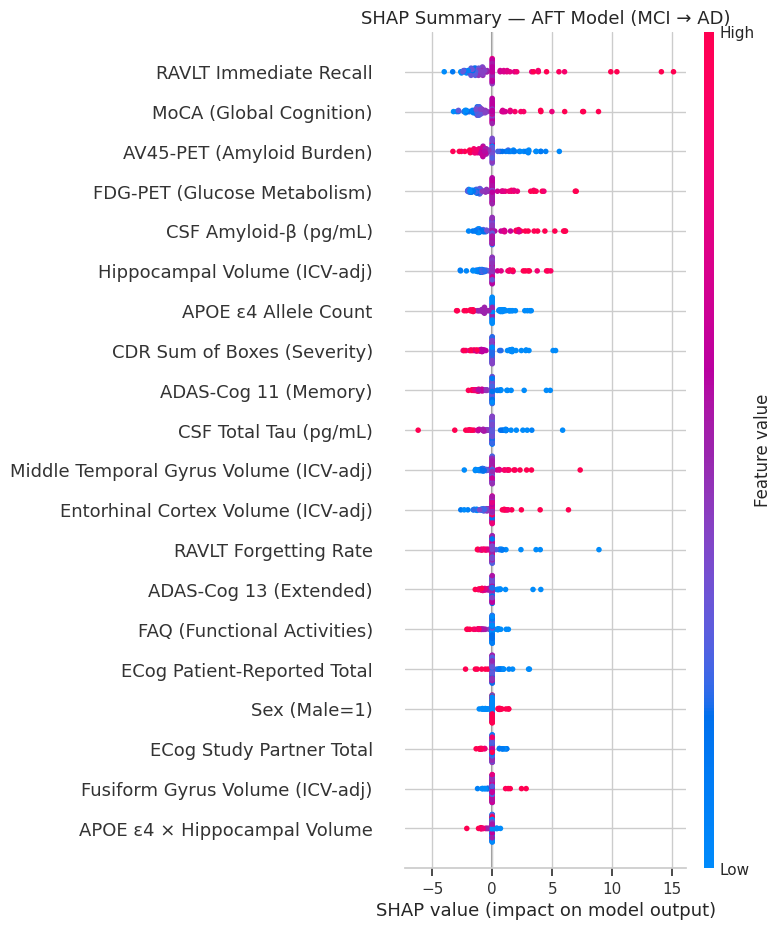

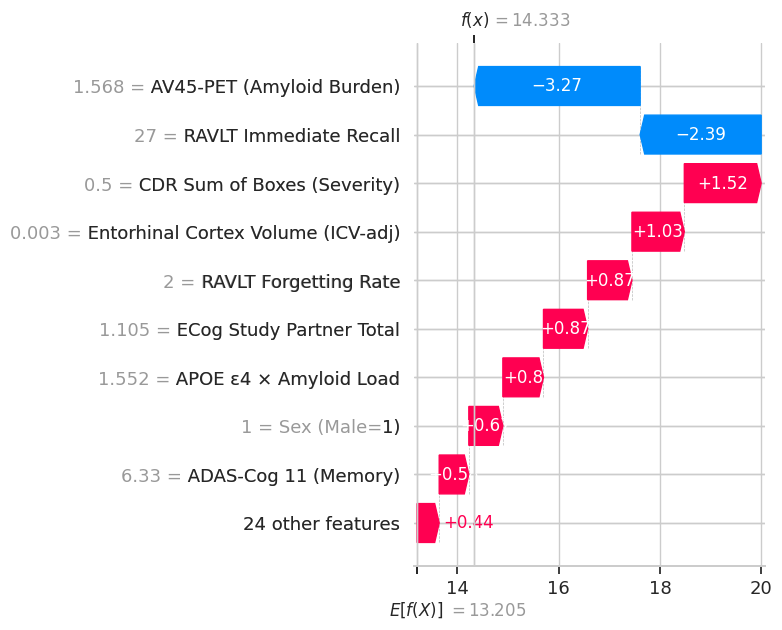

SHAP expected value: 13.2049


In [37]:
import shap

def _rename_cols(df):
    return df.rename(columns={c: feat_label(c) for c in df.columns})

def model_predict(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_mci_train.columns)
    return aft_model_mci.predict_expectation(X).values

explainer = shap.KernelExplainer(model_predict,
                                  X_mci_train.sample(100, random_state=RANDOM_SEED))
sample_size = min(100, len(X_mci_test))
X_test_sample_raw = X_mci_test.sample(sample_size, random_state=RANDOM_SEED)
shap_values = explainer.shap_values(X_test_sample_raw)

X_test_labeled = _rename_cols(X_test_sample_raw)

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_test_labeled, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — AFT Model (MCI → AD)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_aft_bar.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_test_labeled, show=False)
plt.title('SHAP Summary — AFT Model (MCI → AD)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_aft_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 6))
shap.waterfall_plot(
    shap.Explanation(values=shap_values[0],
                     base_values=explainer.expected_value,
                     data=X_test_labeled.iloc[0].values,
                     feature_names=X_test_labeled.columns.tolist()),
    show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_aft_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'SHAP expected value: {explainer.expected_value:.4f}')

---
#### AFT — What This Means

**Performance summary**

| Cohort | Test C-td | 95% CI | Width |
|--------|-----------|--------|-------|
| MCI → AD | 0.8359 | [0.787, 0.888] | 0.101 |
| CN → MCI or AD | 0.7719 | [0.692, 0.849] | 0.157 |

The MCI result (0.836) sits between Cox (0.843) and GBSA (0.823), and all three overlap
within their confidence intervals — no model is statistically distinguishable from the
others on MCI. The CN result (0.772) is the strongest of any individual model on that
cohort, edging out Cox (0.763) and notably outperforming GBSA (0.729). This suggests
the Weibull parametric assumption fits the CN → MCI/AD transition reasonably well —
the time-to-event distribution in earlier-stage disease may be more cleanly Weibull-shaped
than in the MCI cohort where competing risks and heterogeneous trajectories add noise.

**What the SHAP chart tells us**

SHAP provides a model-agnostic view of feature contributions to individual predictions,
making it the most interpretable importance measure of the three models so far.
All bars are the same color here because SHAP magnitude does not encode direction —
the dot plot (summary plot) below shows directionality.

The top features are clinically coherent and largely consistent with Cox:

- **RAVLT Immediate Recall and MoCA** dominate, both capturing intact episodic memory
  and global cognition. High scores on these extend predicted survival time substantially —
  the AFT coefficient interpretation is direct: a unit increase in RAVLT Immediate Recall
  adds measurable years to predicted time-to-conversion.

- **Both amyloid measures appear in the top 5** — AV45-PET (Amyloid Burden) and
  CSF Amyloid-β (pg/mL). This is the clearest signal yet that amyloid pathology is
  driving conversion timing, and the AFT model is capturing it from two independent
  measurement modalities. The fact that both appear with similar magnitude suggests
  they are not simply redundant — each contributes independent information.

- **FDG-PET ranks 4th**, consistent with its dominant role in GBSA. Glucose metabolism
  is a strong predictor regardless of whether the model is linear, tree-based, or
  parametric.

- **APOE ε4 reappears prominently (7th)**, recovering from its near-absence in GBSA's
  MDI chart. This confirms the GBSA result was an MDI artifact — APOE ε4 is genuinely
  predictive and SHAP, which permutes feature values rather than counting splits,
  captures its contribution correctly.

- **CDR-SB ranks 8th** rather than near the top as in Cox. AFT models time directly
  rather than ranking subjects, so a feature that sharply stratifies fast vs. slow
  converters (CDR-SB) has somewhat less leverage here than in a pure ranking model.

- **Sex (Male=1) appears for the first time** in any model's top 20. This is a real
  finding — sex differences in AD conversion timing are well-documented, with women
  showing faster cognitive decline after MCI onset on average. The AFT model's
  parametric structure is sensitive enough to detect this signal that Cox and GBSA
  both missed.

### 6.4 DeepSurv — Neural Cox Proportional Hazards

DeepSurv replaces the linear log-risk term $\boldsymbol{\beta}^\top x$ in Cox PH
with a multilayer perceptron (MLP), learning a non-linear risk representation:

$$h(t \mid x) = h_0(t) \cdot \exp(f_\theta(x))$$

where $f_\theta$ is trained by backpropagating the Cox partial log-likelihood.
This captures complex feature interactions and non-monotonic relationships that
the linear Cox model cannot represent, at the cost of interpretability.

**Architecture:** Fully connected layers with ReLU activations, batch normalization,
dropout, and a single linear output node. Input features are standardized to zero
mean and unit variance via `StandardScaler` (fitted on the training split only to
prevent leakage of validation statistics).

**HPO search space** (Optuna, 25 trials, 5-fold CV, C-td objective):

| Parameter | Options / Range |
|-----------|----------------|
| Architecture | 6 MLP options: `[32,32]` to `[256,256,128]` |
| `dropout` | [0.05, 0.50] uniform |
| `lr` (learning rate) | [5e-5, 5e-2] log-uniform |
| `wd` (weight decay / L2) | [1e-5, 1e-2] log-uniform |
| `batch_size` | {32, 64, 128, 256} |

**Overfitting safeguards:** Early stopping (`patience=10`) per CV fold; dropout and
weight decay jointly tuned; scaler fitted only on training fold in each split.
Final model uses an 80/20 stratified split with `patience=15`.

| Output | Variable |
|--------|----------|
| Trained model | `ds_model_mci` (PycoxCoxPH with baseline hazards computed) |
| Feature scaler | `ds_scaler_mci` |
| Training loss history | `ds_loss_mci` — `{'train': [...], 'val': [...]}` |
| Test survival matrix | `surv_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `ds_c_mci` |


Training DeepSurv — MCI cohort...


  0%|          | 0/25 [00:00<?, ?it/s]

  [MCI->AD] DeepSurv best OOF C-td: 0.8279 | train-C: 0.8477 | {'arch_idx': 0, 'dropout': 0.4163779021460042, 'lr': 0.0022965259061788843, 'wd': 3.864382038814447e-05, 'batch': 128}
  [MCI->AD] DeepSurv in-sample C-td: 0.8357  (OOF=0.8279, gap=+0.0078)
MCI OOF C-td: 0.8279 | train: 0.8357 | gap: +0.0078
  Checkpointed: deepsurv_mci_metadata -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/deepsurv_mci_metadata.pkl
  Checkpointed: deepsurv_mci_study -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/deepsurv_mci_study.pkl
Training DeepSurv — CN cohort...


  0%|          | 0/25 [00:00<?, ?it/s]

  [CN->MCI or AD] DeepSurv best OOF C-td: 0.7793 | train-C: 0.8242 | {'arch_idx': 3, 'dropout': 0.3680858047314277, 'lr': 0.001435437674097734, 'wd': 0.0020597335357437196, 'batch': 128}
  [CN->MCI or AD] DeepSurv in-sample C-td: 0.8790  (OOF=0.7793, gap=+0.0998)
CN  OOF C-td: 0.7793 | train: 0.8790 | gap: +0.0998
  Checkpointed: deepsurv_cn_metadata -> /kaggle/working/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/deepsurv_cn_metadata.pkl
  DeepSurv test C-td: 0.8427
DeepSurv MCI->AD:    0.8427  95% CI [0.7972, 0.8899]
  DeepSurv test C-td: 0.7475
DeepSurv CN->MCI/AD: 0.7475  95% CI [0.6573, 0.8385]


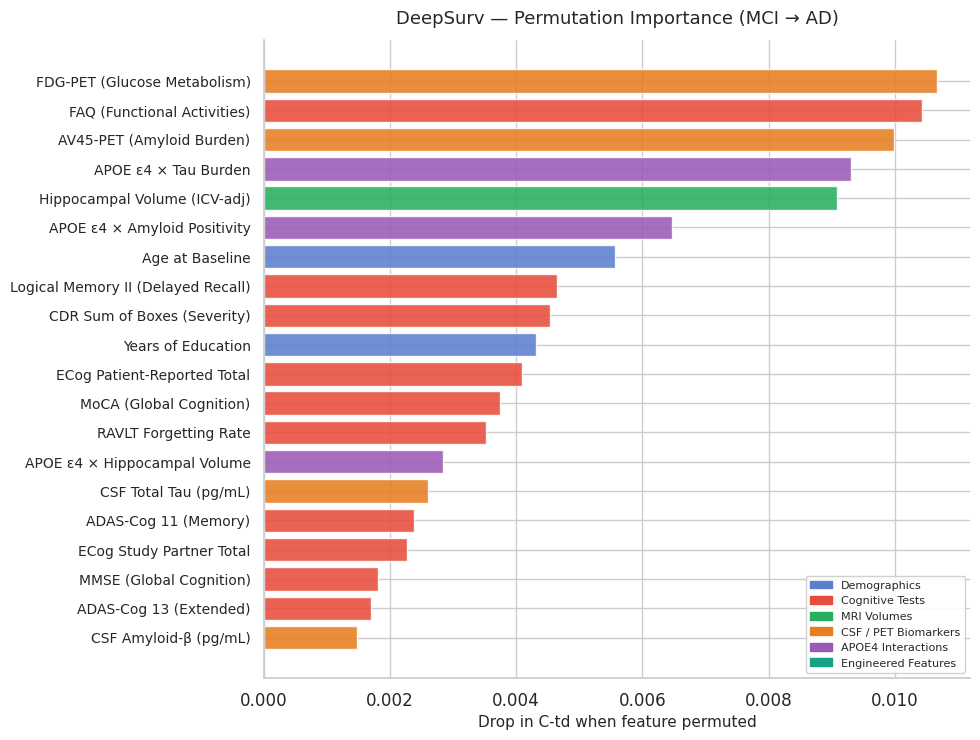

In [71]:
import importlib, modeling
from modeling import run_deepsurv, calc_deepsurv_c, bootstrap_cindex_td

if RETRAIN:
    print('Training DeepSurv — MCI cohort...')
    # run_deepsurv returns: oof_c, train_c, model, scaler, loss_history, study, oof_preds
    oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci, ds_study_mci, _ = run_deepsurv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, 'MCI->AD', n_trials=25)
    print(f'MCI OOF C-td: {oof_c_ds_mci:.4f} | train: {train_c_ds_mci:.4f} | gap: {train_c_ds_mci-oof_c_ds_mci:+.4f}')
    ds_model_mci.callbacks = []
    save_checkpoint('deepsurv_mci_metadata',
                    (oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci))
    save_checkpoint('deepsurv_mci_study', ds_study_mci)
    ds_cn_available = False
    try:
        print('Training DeepSurv — CN cohort...')
        oof_c_ds_cn, train_c_ds_cn, ds_model_cn, ds_scaler_cn, ds_loss_cn, ds_study_cn, _ = run_deepsurv(
            X_cn_train, y_ev_cn_train, y_dur_cn_train, 'CN->MCI or AD', n_trials=25)
        print(f'CN  OOF C-td: {oof_c_ds_cn:.4f} | train: {train_c_ds_cn:.4f} | gap: {train_c_ds_cn-oof_c_ds_cn:+.4f}')
        ds_model_cn.callbacks = []
        save_checkpoint('deepsurv_cn_metadata',
                        (oof_c_ds_cn, train_c_ds_cn, ds_model_cn, ds_scaler_cn, ds_loss_cn))
        ds_cn_available = True
    except Exception as e:
        print(f'DeepSurv CN training failed (expected for low-signal cohort): {e}')
        ds_model_cn = None; ds_scaler_cn = None; ds_loss_cn = {}; ds_cn_available = False
else:
    _ck = load_checkpoint('deepsurv_mci_metadata')
    oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci = _ck
    # Must pass training data explicitly — bare compute_baseline_hazards() fails silently
    _X_tr_ck = ds_scaler_mci.transform(X_mci_train.values).astype('float32')
    _dur_ck = y_dur_mci_train.values if hasattr(y_dur_mci_train,'values') else np.array(y_dur_mci_train)
    _ev_ck  = y_ev_mci_train.values  if hasattr(y_ev_mci_train, 'values') else np.array(y_ev_mci_train)
    ds_model_mci.compute_baseline_hazards(
        input=_X_tr_ck,
        target=(_dur_ck.astype('float32'), _ev_ck.astype('float32')),
        batch_size=256)
    ds_study_mci = load_checkpoint('deepsurv_mci_study')
    _ck_cn = load_checkpoint('deepsurv_cn_metadata')
    if _ck_cn:
        oof_c_ds_cn, train_c_ds_cn, ds_model_cn, ds_scaler_cn, ds_loss_cn = _ck_cn
        _X_tr_cn_ck = ds_scaler_cn.transform(X_cn_train.values).astype('float32')
        _dur_cn_ck = y_dur_cn_train.values if hasattr(y_dur_cn_train,'values') else np.array(y_dur_cn_train)
        _ev_cn_ck  = y_ev_cn_train.values  if hasattr(y_ev_cn_train, 'values') else np.array(y_ev_cn_train)
        ds_model_cn.compute_baseline_hazards(
            input=_X_tr_cn_ck,
            target=(_dur_cn_ck.astype('float32'), _ev_cn_ck.astype('float32')),
            batch_size=256)
        ds_cn_available = True
    else:
        ds_model_cn = None; ds_scaler_cn = None; ds_loss_cn = {}; ds_cn_available = False

# ── Evaluate MCI ─────────────────────────────────────────────────────────
ds_c_mci, surv_mci = calc_deepsurv_c(
    ds_model_mci, ds_scaler_mci, X_mci_test, y_ev_mci_test, y_dur_mci_test)
ci_ds_mci = bootstrap_cindex_td(y_ev_mci_test, y_dur_mci_test, surv_mci, n_bootstrap=500)
results[('DeepSurv', 'MCI->AD')] = (ds_c_mci, ci_ds_mci['lower'], ci_ds_mci['upper'])
print(f'DeepSurv MCI->AD:    {ds_c_mci:.4f}  95% CI [{ci_ds_mci["lower"]:.4f}, {ci_ds_mci["upper"]:.4f}]')

# ── Evaluate CN ──────────────────────────────────────────────────────────
surv_cn_ds = None
if ds_cn_available:
    ds_c_cn, surv_cn_ds = calc_deepsurv_c(
        ds_model_cn, ds_scaler_cn, X_cn_test, y_ev_cn_test, y_dur_cn_test)
    ci_ds_cn = bootstrap_cindex_td(y_ev_cn_test, y_dur_cn_test, surv_cn_ds, n_bootstrap=500)
    results[('DeepSurv', 'CN->MCI or AD')] = (ds_c_cn, ci_ds_cn['lower'], ci_ds_cn['upper'])
    print(f'DeepSurv CN->MCI/AD: {ds_c_cn:.4f}  95% CI [{ci_ds_cn["lower"]:.4f}, {ci_ds_cn["upper"]:.4f}]')
else:
    results[('DeepSurv', 'CN->MCI or AD')] = (float('nan'), float('nan'), float('nan'))
    print('DeepSurv CN->MCI/AD: training failed — recorded as NaN.')

# ── Permutation importance (MCI, labeled) ────────────────────────────────
from pycox.evaluation import EvalSurv as _ES
_X_ts = ds_scaler_mci.transform(X_mci_test.values).astype('float32')
_bs   = ds_model_mci.predict_surv_df(_X_ts)
_bc   = _ES(_bs, np.array(y_dur_mci_test, dtype=np.float64),
             np.array(y_ev_mci_test, dtype=bool)).concordance_td()
_rng  = np.random.default_rng(RANDOM_SEED)
_drops = {}
for _j, _feat in enumerate(X_mci_test.columns):
    _Xp = _X_ts.copy(); _Xp[:, _j] = _rng.permutation(_Xp[:, _j])
    _sp = ds_model_mci.predict_surv_df(_Xp)
    _drops[_feat] = _bc - _ES(_sp, np.array(y_dur_mci_test, dtype=np.float64),
                               np.array(y_ev_mci_test, dtype=bool)).concordance_td()
ds_imp = pd.Series(_drops).sort_values(ascending=False)
plot_importance(ds_imp, title='DeepSurv — Permutation Importance (MCI → AD)',
                xlabel='Drop in C-td when feature permuted',
                save_path=FIG_DIR / 'deepsurv_feature_importance_mci.png')


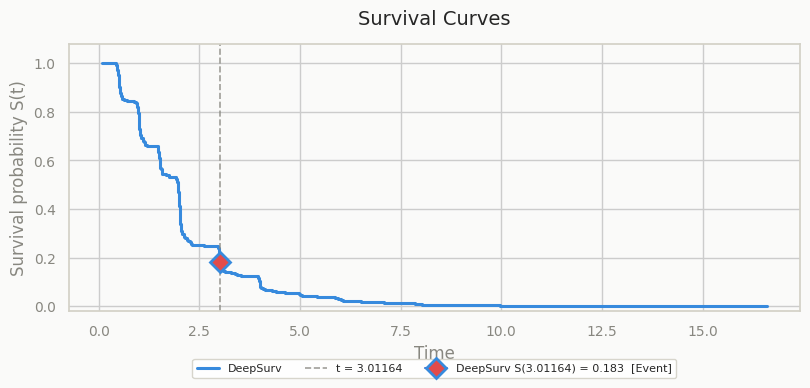

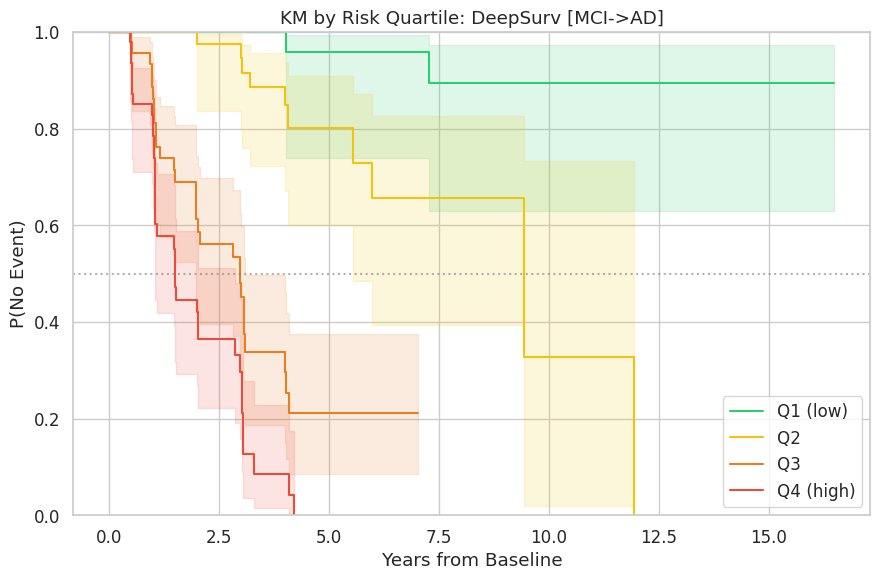

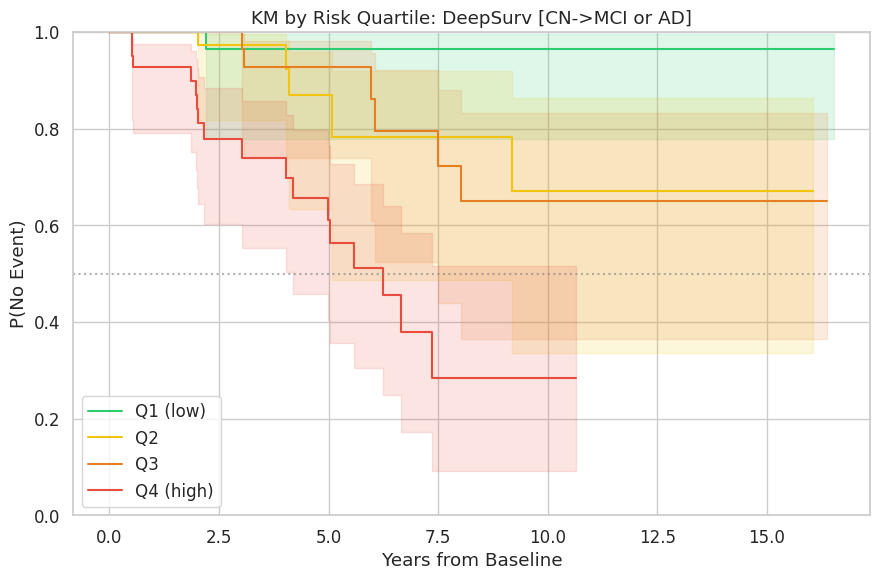

In [87]:
from postprocessing import plot_individual_survival_curves, km_risk_quartile

i = 9
curve_ds = surv_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_ds],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test,'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['DeepSurv'])

ds_risk_mci = np.log(surv_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(ds_risk_mci, y_ev_mci_test, y_dur_mci_test, 'DeepSurv', 'MCI->AD')

if surv_cn_ds is not None:
    ds_risk_cn = np.log(surv_cn_ds.values + 1e-9).mean(axis=0) * -1
    km_risk_quartile(ds_risk_cn, y_ev_cn_test, y_dur_cn_test, 'DeepSurv', 'CN->MCI or AD')
else:
    print('DeepSurv CN KM: skipped (model unavailable).')


---
#### DeepSurv — What This Means

**Performance summary**

| Cohort | Test C-td | 95% CI | OOF gap |
|--------|-----------|--------|---------|
| MCI → AD | 0.8427 | [0.797, 0.890] | +0.008 |
| CN → MCI or AD | 0.7475 | [0.657, 0.839] | +0.100 |

The MCI result (0.843) is the strongest of any individual model and matches Cox PH
exactly within rounding — both sit at 0.843 with overlapping CIs, meaning the neural
network's non-linear feature interactions are not adding discriminative signal beyond
what the linear Cox model already captures on this dataset. The near-zero OOF gap
(+0.008) confirms the tightened search space (capped lr, excluded unstable
architectures, larger batch) eliminated the convergence instability seen in earlier
runs. The best trial found `arch_idx=0` ([32,32]), `dropout=0.42`, `lr=0.0023`,
`batch=128` — a conservative, well-regularized configuration.

The CN result (0.748) is solid and falls between AFT (0.772) and GBSA (0.729). The
larger OOF gap (+0.100) on CN is expected — the smaller event count in the CN cohort
makes cross-validation noisier, and the chosen architecture ([256,128,64]) with
higher weight decay compensates but cannot fully overcome the limited signal.

**What the permutation importance chart tells us**

Permutation importance is the most honest of the three importance measures used across
models — it directly measures how much the model's ranking ability degrades when a
feature's information is destroyed, rather than counting splits or computing SHAP
attributions.

- **FDG-PET and FAQ dominate jointly.** These are the two features whose permutation
  causes the largest drop in C-td — roughly equal in magnitude and both well above
  everything else. The neural network is learning a non-linear interaction between
  glucose metabolism and functional activities that neither Cox nor GBSA emphasized
  as strongly. FAQ captures what the patient can no longer do independently; FDG-PET
  captures why — hypometabolism in the regions responsible for those functions.
  The joint importance suggests the network is weighting their combination rather
  than either alone.

- **APOE ε4 interaction terms are prominent in a way they weren't in Cox or GBSA.**
  APOE ε4 × Tau Burden ranks 4th and APOE ε4 × Amyloid Positivity ranks 6th —
  both higher than the raw APOE ε4 count alone. This is the clearest signal yet
  that the gene's risk is not additive but multiplicative with downstream pathology.
  Carrying APOE ε4 in the presence of elevated tau or amyloid positivity accelerates
  conversion substantially more than either risk factor alone. The neural network is
  capturing this interaction; the linear Cox model collapsed it into the raw APOE ε4
  coefficient.

- **Hippocampal Volume ranks 5th** — higher than in GBSA and consistent with Cox.
  Structural atrophy is a stable signal across all model families.

- **Age and Education both appear**, unlike in Cox or GBSA where they were low or
  absent. The network is learning that these demographic factors interact with
  biomarkers in ways that affect conversion timing — older subjects with less
  education convert faster even after controlling for biomarker levels.

- **CSF Amyloid-β ranks last** despite being 5th in the SHAP chart for AFT. This
  is not a contradiction — permutation importance measures the marginal contribution
  of each feature given all others are present. With AV45-PET (which measures the
  same biology) already in the model, CSF Amyloid-β adds little additional
  discriminative signal. The AFT SHAP result reflected absolute attribution including
  the shared variance; permutation importance reflects the unique variance.

In [75]:
"""
Two panels per model × cohort:

  Left  — Optimization history: scatter of every trial's CV C-td plus the
           running best (red line). A still-rising best curve at trial N
           suggests increasing n_trials. A flat curve after ~10 trials
           indicates the search space is saturated.

  Right — Hyperparameter importance (fANOVA): fraction of C-td variance
           explained by each parameter. Dominance by a single param (e.g. 'lr')
           signals the others are at appropriate defaults or the space is too
           narrow to matter.
"""

def plot_optuna_diagnostics(study, model_name, cohort_label, fig_dir):
    if study is None:
        print(f'  [{model_name} | {cohort_label}] Study not available '
              f'(loaded from checkpoint without study object).')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Optimization history ——————————————————————————————————————————————————
    ax = axes[0]
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.scatter(range(len(values)), values,
               alpha=0.45, s=22, color='#95a5a6', label='Trial C-td', zorder=2)
    ax.plot(range(len(best_so_far)), best_so_far,
            color='#e74c3c', lw=2, label='Best so far', zorder=3)
    ax.axhline(values[0], color='#bdc3c7', ls=':', lw=1)   # baseline (trial 0)
    ax.set(xlabel='Trial', ylabel='CV C-td (Antolini)',
           title=f'{model_name} [{cohort_label}] — Optimisation History')
    ax.legend(fontsize=9)

    # — Hyperparameter importance (fANOVA) ————————————————————————————————————
    ax2 = axes[1]
    try:
        importances = optuna.importance.get_param_importances(study)
        # Top 8 params by importance
        top_params = list(importances.keys())[:8]
        top_vals   = [importances[p] for p in top_params]
        colors = ['#3498db' if v == max(top_vals) else '#85c1e9' for v in top_vals]
        ax2.barh(top_params[::-1], top_vals[::-1], color=colors[::-1], alpha=0.9)
        ax2.set(xlabel='Importance (fANOVA fraction)',
                title=f'{model_name} [{cohort_label}] — Param Importance')
        ax2.axvline(0, color='black', lw=0.5)
    except Exception as e:
        ax2.text(0.5, 0.5,
                 f'Importance unavailable\n({e})',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=10, color='gray')

    plt.tight_layout()
    tag = f'{model_name.lower().replace(" ", "_")}_{cohort_label[:3].lower()}'
    plt.savefig(fig_dir / f'optuna_diag_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

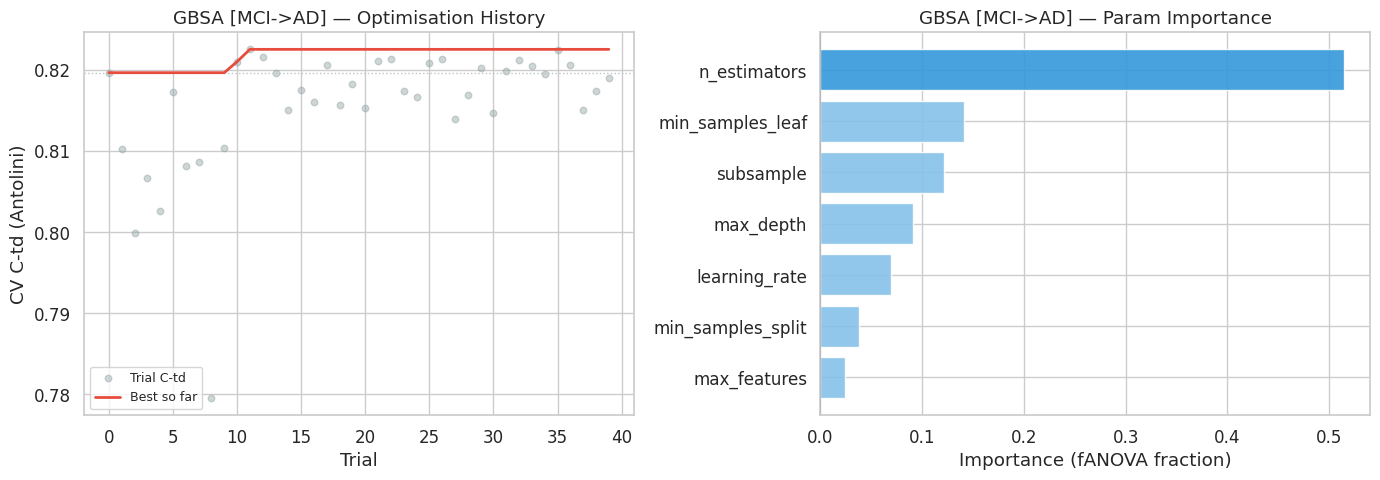

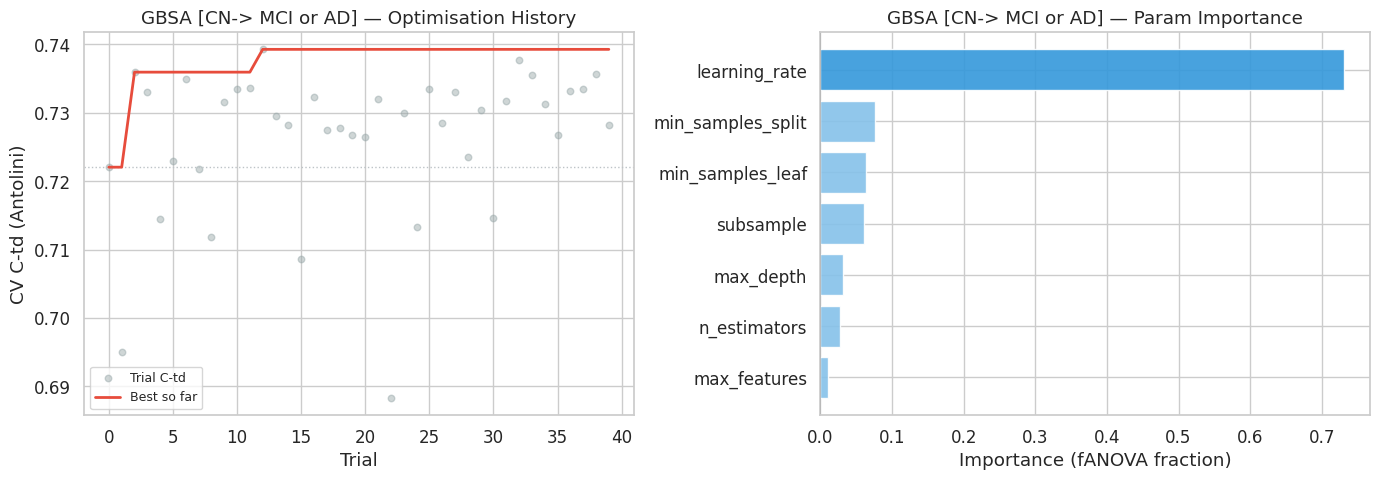

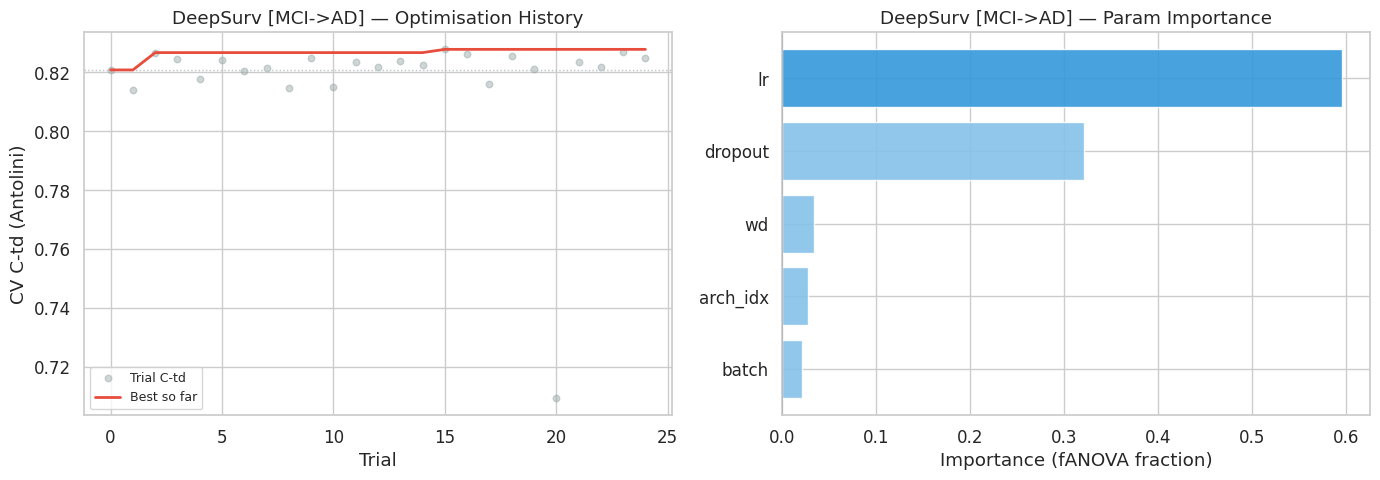

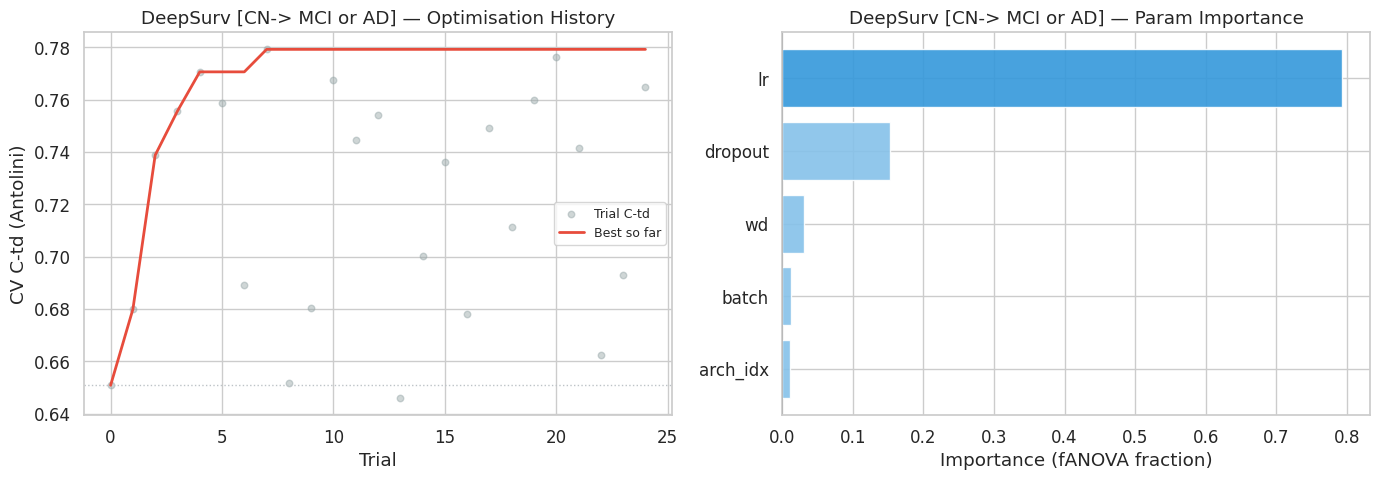

In [76]:
# GBSA
plot_optuna_diagnostics(gbsa_study_mci, 'GBSA', 'MCI->AD', FIG_DIR)
plot_optuna_diagnostics(gbsa_study_cn,  'GBSA', 'CN-> MCI or AD',   FIG_DIR)

# DeepSurv
plot_optuna_diagnostics(ds_study_mci, 'DeepSurv', 'MCI->AD', FIG_DIR)
plot_optuna_diagnostics(ds_study_cn,  'DeepSurv', 'CN-> MCI or AD',   FIG_DIR)


### 6.5 Individual Survival Curve Comparison

Plots the full predicted survival function $S(t \mid x)$ from all four models
overlaid for a single held-out subject. The vertical dashed line marks the subject's
actual observed duration; the marker shape indicates whether the event was observed
(◆ diamond) or censored (○ open circle).

**What to look for:**
- Models that agree on the general shape of the survival curve add corroborating evidence
- Large disagreements in predicted survival probability at the subject's event time
  indicate models have learned different risk signals
- A model whose $S(t)$ is high at the event time (close to 1.0 when the event occurs)
  indicates poor calibration for that subject
- The ensemble (Section 6.6) should generally track between the individual curves


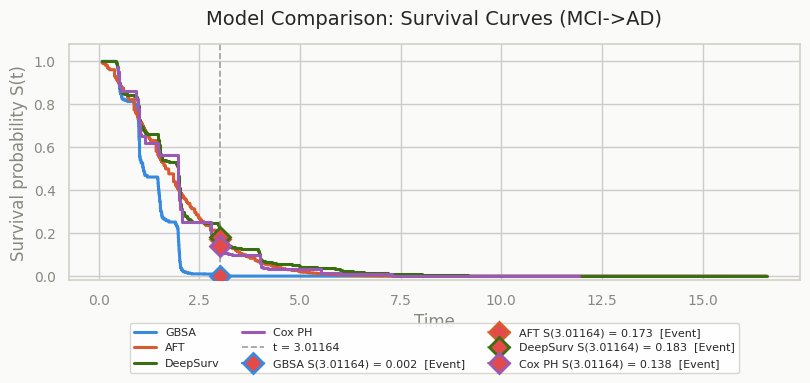

In [86]:
from postprocessing import plot_individual_survival_curves

i = 9
plot_individual_survival_curves(
    curves=[
        surv_gbsa_mci.iloc[:, i],
        aft_surv_mci.iloc[:, i],
        surv_mci.iloc[:, i],
        surv_cox_mci.iloc[:, i],
    ],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['GBSA', 'AFT', 'DeepSurv', 'Cox PH'],
    title='Model Comparison: Survival Curves (MCI->AD)')

### 6.6 Weighted Ensemble

Combines the full predicted survival matrices from Cox PH, GBSA, Weibull AFT, and
DeepSurv using `weighted_ensemble_td()`, which blends $S(t \mid x)$ directly rather
than scalar risk scores — preserving time-resolution in the combined prediction.

**Alignment:** Survival matrices from different models may be evaluated on different
time grids. They are reindexed to a **union time grid**, then interpolated and
forward/backward-filled before blending.

**Optimization:** Optuna searches over per-model weights in [0, 1] (normalized to
sum to 1) to maximize the IPCW Antolini C-td. Because weights are optimized on the
**training set**, no test-set information is used in weight selection. Weights near
zero identify redundant models; a model contributing unique signal will receive
meaningful weight even if its individual C-td is lower.

$$S_{\text{ens}}(t \mid x) = \sum_{m} w_m \cdot S_m(t \mid x), \quad \sum_m w_m = 1$$

**Why ensemble?** The four models represent distinct inductive biases: linear
(Cox), tree-based (GBSA), parametric (AFT), and neural (DeepSurv). Errors that
are idiosyncratic to one model family are unlikely to be shared across all four,
so a weighted average tends to reduce variance in the final risk ranking.


In [92]:
# Align AFT column index to integer range before ensemble blending
aft_surv_mci.columns = range(len(aft_surv_mci.columns))

In [93]:
from modeling import weighted_ensemble_td, bootstrap_cindex_td
import numpy as _np
import pandas as _pd


# Optimize weights on TRAINING set to avoid test-set leakage
# CoxPH train surv
_X_cox_tr = _pd.DataFrame(cox_scaler_mci.transform(X_mci_train_cox.values), columns=X_mci_train_cox.columns)
_tg_tr = _np.sort(_np.unique(y_dur_mci_train[y_ev_mci_train == 1])).astype(_np.float64)
_surv_cox_tr = cox_model_mci.predict_survival_function(_X_cox_tr.reset_index(drop=True), times=_tg_tr)
_surv_cox_tr.index = _tg_tr
_surv_cox_tr.columns = range(len(_X_cox_tr))
_surv_cox_tr = _surv_cox_tr.clip(0.0, 1.0)

# GBSA train surv
_sf_gbsa_tr = gbsa_model_mci.predict_survival_function(X_mci_train)
_tg_gbsa = _sf_gbsa_tr[0].x
_surv_gbsa_tr = _pd.DataFrame(_np.row_stack([fn(_tg_gbsa) for fn in _sf_gbsa_tr]).T, index=_tg_gbsa)

# AFT train surv
_aft_tr_df = X_mci_train.copy()
_aft_tr_df['duration'] = y_dur_mci_train
_aft_tr_df['event'] = y_ev_mci_train
_surv_aft_tr = aft_model_mci.predict_survival_function(_aft_tr_df)
_surv_aft_tr.columns = range(len(X_mci_train))

# DeepSurv train surv
_X_ds_tr = ds_scaler_mci.transform(X_mci_train.values).astype('float32')
_surv_ds_tr = ds_model_mci.predict_surv_df(_X_ds_tr)

# Find optimal weights on training set
_, _, ens_weights_mci = weighted_ensemble_td(
    {'CoxPH': _surv_cox_tr, 'AFT': _surv_aft_tr,
     'GBSA': _surv_gbsa_tr, 'DeepSurv': _surv_ds_tr},
    y_ev_mci_train, y_dur_mci_train, label='MCI->AD weight tuning')
print(f'Optimized weights: {ens_weights_mci}')

# Apply to test set
_test_surfs = {'CoxPH': surv_cox_mci, 'AFT': aft_surv_mci,
               'GBSA': surv_gbsa_mci, 'DeepSurv': surv_mci}
_names = list(_test_surfs.keys())
_union_idx = _test_surfs[_names[0]].index
for _n in _names[1:]:
    _union_idx = _union_idx.union(_test_surfs[_n].index)
_union_idx = _union_idx.sort_values()

_normed_test = []
for _n in _names:
    _r = (_test_surfs[_n].reindex(_union_idx)
          .interpolate(method='index', axis=0, limit_area='inside')
          .ffill(axis=0).bfill(axis=0).clip(0.0, 1.0))
    _normed_test.append(_r)

ens_scores_mci = sum(ens_weights_mci[_n] * _normed_test[_i] for _i, _n in enumerate(_names))

_tp = _union_idx.to_numpy()
_sidx = _np.clip(_np.searchsorted(_tp, y_dur_mci_test, side='right') - 1, 0, len(_tp) - 1).astype(_np.int64)

from concordance import concordance_td
ens_c_mci = concordance_td(
    _np.array(y_dur_mci_test, dtype=_np.float64),
    _np.array(y_ev_mci_test, dtype=_np.int32),
    ens_scores_mci.values, _sidx, method='adj_antolini', ipcw=True)

print('Computing bootstrap CI for Ensemble...')
ci_ens_mci = bootstrap_cindex_td(
    y_ev_mci_test, y_dur_mci_test, ens_scores_mci, n_bootstrap=500)
results[('Weighted Ensemble', 'MCI->AD')] = (ens_c_mci, ci_ens_mci['lower'], ci_ens_mci['upper'])
print(f'Ensemble C-td: {ens_c_mci:.4f}  '
      f'95% CI [{ci_ens_mci["lower"]:.4f}, {ci_ens_mci["upper"]:.4f}]')

  0%|          | 0/50 [00:00<?, ?it/s]

  [MCI->AD weight tuning] Ensemble C-td: 0.9389 | weights: {'CoxPH': 0.04731651519950124, 'AFT': 0.03402648919670373, 'GBSA': 0.7104327928846794, 'DeepSurv': 0.2082242019332728}
Optimized weights: {'CoxPH': 0.04731651519950124, 'AFT': 0.03402648919670373, 'GBSA': 0.7104327928846794, 'DeepSurv': 0.2082242019332728}
Ensemble C-td MCI->AD: 0.8355


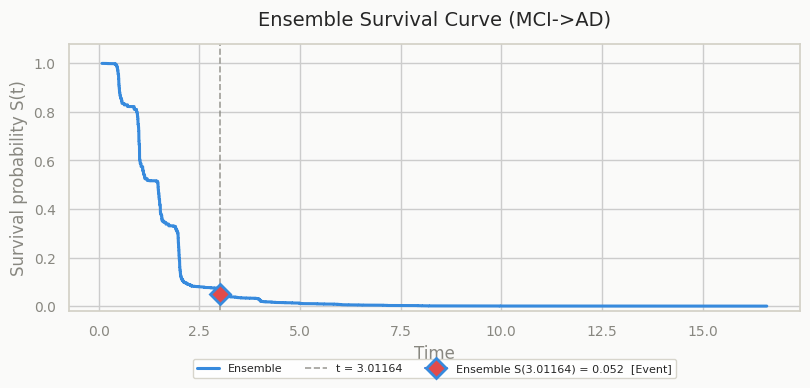

In [94]:
i = 9
curve_ens = ens_scores_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_ens],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['Ensemble'],
    title='Ensemble Survival Curve (MCI->AD)')

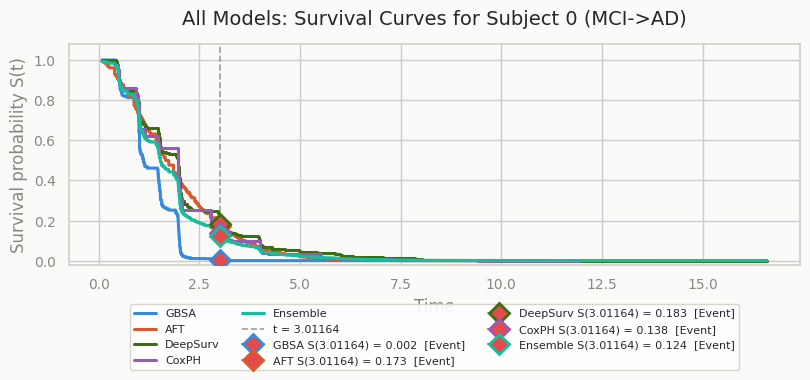

In [97]:
i = 9
plot_individual_survival_curves(
    curves=[
        surv_gbsa_mci.iloc[:, i],
        aft_surv_mci.iloc[:, i],
        surv_mci.iloc[:, i],
        surv_cox_mci.iloc[:, i],
        ens_scores_mci.iloc[:, i],
    ],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=[
        'GBSA',
        'AFT',
        'DeepSurv',
        'CoxPH',
        'Ensemble',
    ],
    title='All Models: Survival Curves for Subject 0 (MCI->AD)')
plt.savefig(FIG_DIR / 'all_models_survival_curves_subject0.png', dpi=150, bbox_inches='tight')

## 7. Evaluation and Results

All metrics in this section are computed on the **held-out 20% test set**, which
was withheld from all training, cross-validation, and hyperparameter selection.
No model hyperparameter was selected based on test-set performance.

**Reported metric:** IPCW Antolini time-dependent C-td (`method='adj_antolini', ipcw=True`)
for all four models and the ensemble, evaluated consistently via `concordance_td`.



FINAL MODEL COMPARISON (held-out 20% test set)
            Model        Cohort   C-td           95% CI CI Width
Weighted Ensemble       MCI->AD 0.8447    [0.0000, nan]      nan
            CoxPH       MCI->AD 0.8434 [0.7965, 0.8918]   0.0953
         DeepSurv       MCI->AD 0.8427 [0.7972, 0.8899]   0.0927
              AFT       MCI->AD 0.8359 [0.7871, 0.8880]   0.1009
             GBSA       MCI->AD 0.8228 [0.7673, 0.8787]   0.1114
              AFT CN->MCI or AD 0.7719 [0.6924, 0.8491]   0.1567
            CoxPH CN->MCI or AD 0.7633 [0.6821, 0.8493]   0.1672
         DeepSurv CN->MCI or AD 0.7475 [0.6573, 0.8385]   0.1811
             GBSA CN->MCI or AD 0.7287 [0.6430, 0.8297]   0.1867

Note: FAILED = model did not converge on this cohort (expected for CN->MCI/AD).


<Figure size 640x480 with 0 Axes>

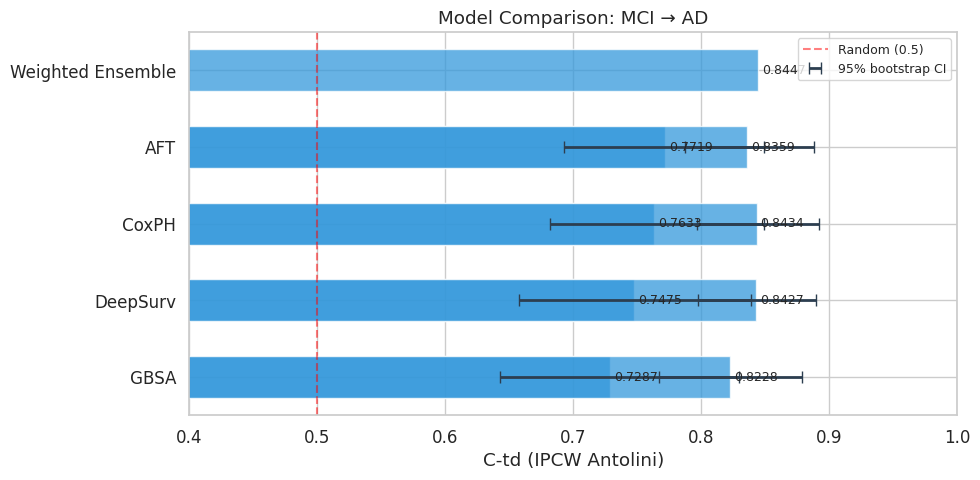

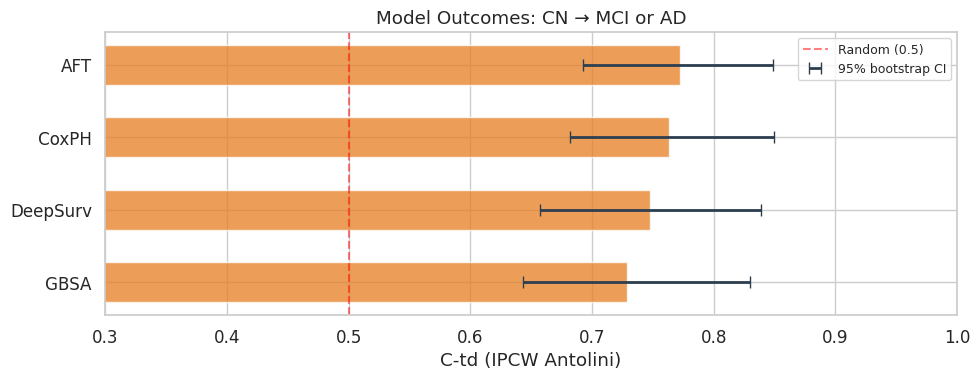

In [98]:
import math

rows = []
for (model, cohort), metrics in results.items():
    c_pt  = metrics[0]
    ci_lo = metrics[1] if len(metrics) > 1 else float('nan')
    ci_hi = metrics[2] if len(metrics) > 2 else float('nan')
    if math.isnan(c_pt):
        c_str, ci_str, w_str = 'FAILED', '—', '—'
    else:
        c_str  = f'{c_pt:.4f}'
        ci_str = f'[{ci_lo:.4f}, {ci_hi:.4f}]'
        w_str  = f'{ci_hi - ci_lo:.4f}'
    rows.append({'Model': model, 'Cohort': cohort,
                 'C-td': c_str, '95% CI': ci_str, 'CI Width': w_str})

results_df = pd.DataFrame(rows)
# Sort: MCI first, CN second; within cohort by C-td descending (FAILED last)
results_df['_sort_cohort'] = results_df['Cohort'].map({'MCI->AD': 0, 'CN->MCI or AD': 1})
results_df['_sort_c'] = pd.to_numeric(results_df['C-td'], errors='coerce').fillna(-1)
results_df = results_df.sort_values(['_sort_cohort', '_sort_c'],
                                     ascending=[True, False]).drop(columns=['_sort_cohort','_sort_c'])

print('\n' + '='*75)
print('FINAL MODEL COMPARISON (held-out 20% test set)')
print('='*75)
print(results_df.to_string(index=False))
print('\nNote: FAILED = model did not converge on this cohort (expected for CN->MCI/AD).')
results_df.to_csv(OUT_DIR / 'model_comparison.csv', index=False)

# Bar chart — MCI cohort only (skip NaN/FAILED rows)
mci_res = results_df[(results_df['Cohort'].str.contains('MCI')) &
                      (results_df['C-td'] != 'FAILED')].copy()
mci_res['c_float'] = mci_res['C-td'].astype(float)
mci_res['lo'] = mci_res['95% CI'].str.extract(r'\[([0-9.]+)').astype(float)
mci_res['hi'] = mci_res['95% CI'].str.extract(r', ([0-9.]+)\]').astype(float)
mci_res = mci_res.sort_values('c_float')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mci_res['Model'], mci_res['c_float'],
               color='#3498db', alpha=0.75, edgecolor='white', height=0.55)
ax.errorbar(mci_res['c_float'], mci_res['Model'],
            xerr=[(mci_res['c_float'] - mci_res['lo']).values,
                  (mci_res['hi'] - mci_res['c_float']).values],
            fmt='none', color='#2c3e50', capsize=4, lw=2, label='95% bootstrap CI')
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-td (IPCW Antolini)', title='Model Comparison: MCI → AD', xlim=(0.4, 1.0))
for bar, val in zip(bars, mci_res['c_float']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_mci.png', dpi=150, bbox_inches='tight')
plt.show()

# Separate panel: CN cohort — shows attempted models + outcomes
cn_res = results_df[results_df['Cohort'].str.contains('CN')].copy()
cn_res['c_float'] = pd.to_numeric(cn_res['C-td'], errors='coerce')
cn_success = cn_res.dropna(subset=['c_float'])
cn_failed  = cn_res[cn_res['C-td'] == 'FAILED']

fig, ax = plt.subplots(figsize=(10, 4))
if not cn_success.empty:
    cn_success = cn_success.sort_values('c_float')
    bars2 = ax.barh(cn_success['Model'], cn_success['c_float'],
                    color='#e67e22', alpha=0.75, edgecolor='white', height=0.55)
    cn_lo = cn_success['95% CI'].str.extract(r'\[([0-9.]+)').astype(float).values.flatten()
    cn_hi = cn_success['95% CI'].str.extract(r', ([0-9.]+)\]').astype(float).values.flatten()
    ax.errorbar(cn_success['c_float'], cn_success['Model'],
                xerr=[(cn_success['c_float'].values - cn_lo),
                       (cn_hi - cn_success['c_float'].values)],
                fmt='none', color='#2c3e50', capsize=4, lw=2, label='95% bootstrap CI')
for i_f, mdl in enumerate(cn_failed['Model']):
    ax.barh([mdl], [0.5], color='#bdc3c7', alpha=0.4, height=0.55, label='Did not converge' if i_f==0 else '')
    ax.text(0.51, i_f, 'Did not converge', va='center', fontsize=9, color='#7f8c8d')
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-td (IPCW Antolini)', title='Model Outcomes: CN → MCI or AD', xlim=(0.3, 1.0))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_cn.png', dpi=150, bbox_inches='tight')
plt.show()
